# OHL Goalkeeper Progression
**Steps covered:** Load Data → Feature Engineering → Feature Selection → Modelling → Validation

> Central question: *Given a goalkeeper's performance in a lower league, can you predict whether he will make it at a higher level?*

## 0 · Setup

In [2]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')

GK_DATA = Path('Data')         
COMP_DIR = GK_DATA / 'competitions'

print('Data folder:', GK_DATA.resolve())
print('Exists:', GK_DATA.exists())

Data folder: C:\Users\angel\Files\UCLL\Semester 4\Advanced AI\Project\Data
Exists: True


c:\Users\angel\Files\UCLL\Semester 4\Advanced AI\Project\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## Step 1 · Load Data

### 1a · Labels

In [3]:
df = pd.read_csv(GK_DATA / 'gk_dataset_final.csv')

print(f'Total keepers: {len(df)}')
print('\nStatus distribution:')
print(df['status'].value_counts())
print('\nDirection distribution:')
print(df['direction'].value_counts())

df.head(3)

Total keepers: 693

Status distribution:
status
STAYED     435
DROPPED    128
PLAYS       99
BENCH       31
Name: count, dtype: int64

Direction distribution:
direction
NONE    435
UP      130
DOWN    128
Name: count, dtype: int64


,playerId,name,age,birthdate,status,origin_team,origin_comp,origin_season,origin_median,origin_matches,current_team,current_comp,current_season,current_median,current_matches,step,direction,origin_match_dirs,current_match_dirs
0,1353,Nils Körber,29.0,1996-11-13,BENCH,SpVgg Greuther Fürth II,regionalliga_bayern,2023-2024,0.287193,1,FC Hansa Rostock,bundesliga_2,2023-2024,0.710515,1.0,0.423322,UP,20240219 FC Bayern München II - SpVgg Greuthe...,20240120 1. FC Nürnberg - FC Hansa Rostock
1,126501,Paul Argney,19.0,2006-05-23,BENCH,Royal Francs Borains,challenger_pro_league,2024-2025,0.348513,1,Le Havre AC,ligue1,2025-2026,0.771221,1.0,0.422708,UP,20250406 RAAL La Louvière - Royal Francs Borains,20260104 Le Havre AC - Angers SCO
2,178234,Pape Sy,28.0,1997-05-02,BENCH,RFC Seraing,challenger_pro_league,2023-2024,0.348513,14,FC Metz,ligue1,2025-2026,0.771221,1.0,0.422708,UP,20230902 KV Oostende - RFC Seraing|20230917 KM...,20251026 LOSC Lille - FC Metz


### 1b · Definition files

In [4]:
with open(GK_DATA / 'player_kpi_definitions.json') as f:
    kpi_defs = {d['id']: d['name'] for d in json.load(f).get('data', [])}

with open(GK_DATA / 'player_score_definitions.json') as f:
    score_defs = {d['id']: d['name'] for d in json.load(f).get('data', [])}

print(f'KPI definitions loaded   : {len(kpi_defs)}')
print(f'Score definitions loaded : {len(score_defs)}')

KPI definitions loaded   : 1458
Score definitions loaded : 134


### 1c · Building a competition folder lookup

Match directories in `origin_match_dirs` are bare folder names like `20230401 Club A - Club B`.  
We index every match folder once so lookups are O(1) instead of scanning 40+ league folders each time.

In [5]:
match_index: dict[str, Path] = {}
for cs_dir in COMP_DIR.iterdir():
    if not cs_dir.is_dir():
        continue
    for match_dir in cs_dir.iterdir():
        if match_dir.is_dir():
            match_index[match_dir.name] = match_dir

print(f'Match folders indexed: {len(match_index):,}')

Match folders indexed: 10,765


### 1d · Loading functions

Two parallel loaders, one for **player_scores** (Level 1, fast) and one for **player_kpis** (Level 2, detailed).  
Both use the shared `match_index` from above and apply the `matchShare >= 0.5` filter.

In [6]:
def parse_match_dirs(raw: str | float) -> list[str]:
    if not isinstance(raw, str) or not raw.strip():
        return []
    return [m.strip() for m in raw.split('|') if m.strip()]


def _iter_players(json_data: dict, squad_key: str):
    yield from json_data.get('data', {}).get(squad_key, {}).get('players', [])


# player_scores loader
def load_keeper_scores(player_id: int, match_dirs_raw: str | float) -> list[dict]:
    records = []
    for mdir in parse_match_dirs(match_dirs_raw):
        match_path = match_index.get(mdir)
        if match_path is None:
            continue

        kpi_path   = match_path / 'player_kpis.json'
        score_path = match_path / 'player_scores.json'
        if not kpi_path.exists() or not score_path.exists():
            continue

        # Step 1: verify player is a GOALKEEPER in player_kpis
        with open(kpi_path) as f:
            kpi_data = json.load(f)

        gk_match_share = None
        for side in ('squadHome', 'squadAway'):
            for p in _iter_players(kpi_data, side):
                if (p.get('id') == player_id
                        and p.get('position') == 'GOALKEEPER'
                        and p.get('matchShare', 0) >= 0.5):
                    gk_match_share = p.get('matchShare')
                    gk_play_duration = p.get('playDuration', 0)
                    break
            if gk_match_share is not None:
                break

        if gk_match_share is None:
            continue   # not a GK or didn't play enough

        # Step 2: grab scores from player_scores.json
        with open(score_path) as f:
            score_data = json.load(f)

        for side in ('squadHome', 'squadAway'):
            for p in _iter_players(score_data, side):
                if p.get('id') == player_id:
                    row = {f'score_{s["playerScoreId"]}': s['value']
                           for s in p.get('playerScores', [])}
                    row['matchShare']   = gk_match_share
                    row['playDuration'] = gk_play_duration
                    records.append(row)
                    break

    return records


# player_kpis loader
def load_keeper_kpis(player_id: int, match_dirs_raw: str | float) -> list[dict]:
    records = []
    for mdir in parse_match_dirs(match_dirs_raw):
        match_path = match_index.get(mdir)
        if match_path is None:
            continue
        kpi_path = match_path / 'player_kpis.json'
        if not kpi_path.exists():
            continue

        with open(kpi_path) as f:
            data = json.load(f).get('data', {})

        for side in ('squadHome', 'squadAway'):
            for p in data.get(side, {}).get('players', []):
                if (p.get('id') == player_id
                        and p.get('position') == 'GOALKEEPER'
                        and p.get('matchShare', 0) >= 0.5):
                    row = {f'kpi_{k["kpiId"]}': k['value'] for k in p.get('kpis', [])}
                    row['matchShare']   = p.get('matchShare')
                    row['playDuration'] = p.get('playDuration', 0)
                    records.append(row)
                    break

    return records


print('Loader functions defined ✓')

Loader functions defined ✓


### 1e · Verification, single keeper

In [7]:
row = df.iloc[0]
scores = load_keeper_scores(row['playerId'], row['origin_match_dirs'])

print(f"Keeper : {row['name']}  (id={row['playerId']})")
print(f"Status : {row['status']}")
print(f"Matches with scores loaded: {len(scores)}")
if scores:
    print(f"Score columns per match   : {len(scores[0])}")
    print("First match (sample):", {k: round(v, 4) for k, v in list(scores[0].items())[:6]})

Keeper : Nils Körber  (id=1353)
Status : BENCH
Matches with scores loaded: 0


---
## Step 2 · Feature Engineering

For each keeper we aggregate all qualifying match records into a single feature vector using **mean** (primary) plus **std** and **match count** as reliability indicators.

### 2a · Build per-keeper feature vectors (player_scores, Level 1)

In [8]:
MIN_MATCHES = 3   # keepers with fewer matches are excluded (unreliable averages)

records = []

for _, row in tqdm(df.iterrows(), total=len(df), desc='Loading scores'):
    matches = load_keeper_scores(row['playerId'], row['origin_match_dirs'])

    if len(matches) < MIN_MATCHES:
        continue

    match_df = pd.DataFrame(matches)

    # Collect all score columns (exclude metadata columns)
    score_cols = [c for c in match_df.columns if c.startswith('score_')]

    feat = {
        'playerId'       : row['playerId'],
        'name'           : row['name'],
        'status'         : row['status'],
        'direction'      : row['direction'],
        'age'            : row['age'],
        'origin_median'  : row['origin_median'],
        'origin_matches' : row['origin_matches'],
        'n_matches_loaded': len(matches),
    }

    for col in score_cols:
        vals = match_df[col].dropna()
        if len(vals) == 0:
            feat[f'mean_{col}'] = np.nan
            feat[f'std_{col}']  = np.nan
        else:
            feat[f'mean_{col}'] = vals.mean()
            feat[f'std_{col}']  = vals.std()

    records.append(feat)

features_df = pd.DataFrame(records)
print(f'Keepers with ≥{MIN_MATCHES} matches : {len(features_df)}')
print(f'Feature columns              : {len(features_df.columns)}')
print('\nStatus breakdown after filter:')
print(features_df['status'].value_counts())

Loading scores: 100%|██████████| 693/693 [00:10<00:00, 64.57it/s] 

Keepers with ≥3 matches : 218
Feature columns              : 276

Status breakdown after filter:
status
STAYED     117
DROPPED     55
PLAYS       37
BENCH        9
Name: count, dtype: int64


### 2b · Rename score columns to better readable names

In [9]:
def rename_score_cols(df: pd.DataFrame, score_defs: dict) -> pd.DataFrame:
    rename_map = {}
    for col in df.columns:
        for prefix in ('mean_score_', 'std_score_'):
            if col.startswith(prefix):
                sid = int(col.replace(prefix, ''))
                readable = score_defs.get(sid, f'SCORE_{sid}')
                rename_map[col] = col.replace(f'score_{sid}', readable)
    return df.rename(columns=rename_map)

features_df = rename_score_cols(features_df, score_defs)
print('Columns renamed to score names ✓')

# Preview
feat_cols = [c for c in features_df.columns if c.startswith('mean_')]
print(f'\nSample feature names ({len(feat_cols)} mean features):')
for c in feat_cols[:10]:
    print(' ', c)

Columns renamed to score names ✓

Sample feature names (134 mean features):
  mean_IMPECT_SCORE_PACKING
  mean_IMPECT_SCORE_WITHOUT_GOALS_PACKING
  mean_IMPECT_SCORE_WITH_POSTSHOT_XG_PACKING
  mean_SCORER_SCORE
  mean_PROGRESSION_SCORE_PACKING
  mean_OFFENSIVE_IMPECT_SCORE_PACKING
  mean_OFFENSIVE_IMPECT_SCORE_WITHOUT_GOALS_PACKING
  mean_OFFENSIVE_IMPECT_SCORE_WITH_POSTSHOT_XG_PACKING
  mean_RECEIVING_SCORE_PACKING
  mean_INTERVENTIONS_SCORE_PACKING


### 2c · Missing value overview

In [10]:
mean_cols = [c for c in features_df.columns if c.startswith('mean_')]
missing_pct = features_df[mean_cols].isna().mean().sort_values(ascending=False)

# Scores missing for > 80% of keepers
high_missing = missing_pct[missing_pct > 0.80]
print(f'Scores missing in >80% of keepers: {len(high_missing)}')
print(high_missing.head(10).to_string())

# Scores with reasonable coverage < 20% missing
good_coverage = missing_pct[missing_pct < 0.20]
print(f'\nScores with <20% missing: {len(good_coverage)}')

Scores missing in >80% of keepers: 6
mean_CORNER_SCORE                    0.995413
mean_RATIO_MINUTES_PER_GOAL          0.990826
mean_RATIO_SHOTS_PER_GOAL            0.990826
mean_RATIO_MINUTES_PER_SHOT_XG       0.917431
mean_RATIO_AERIAL_DUELS_OFFENSIVE    0.912844
mean_RATIO_MINUTES_PER_ASSIST        0.885321

Scores with <20% missing: 111


### 2d · Binary target variables

Following the project briefing, we create two binary targets:

| Target | Positive class | Rationale |
|--------|---------------|-----------|
| `y_plays` | PLAYS | Main question: will the keeper break through? |
| `y_up` | PLAYS + BENCH | Did the transfer result in any higher-level exposure? |

The y_plays variable is the binary target variable for the main classification problem:

- 1 (positive) = the keeper has status PLAYS — he transferred to a stronger league and plays regularly (≥3 matches)
- 0 (negative) = everyone else — BENCH, STAYED, or DROPPED

In [11]:
features_df['y_plays'] = (features_df['status'] == 'PLAYS').astype(int)
features_df['y_up']    = features_df['status'].isin(['PLAYS', 'BENCH']).astype(int)

print('Binary target counts:')
print(features_df[['y_plays', 'y_up']].value_counts())

Binary target counts:
y_plays  y_up
0        0       172
1        1        37
0        1         9
Name: count, dtype: int64


### 2e · Exploratory distributions, GK specific scores by status

Box plots for the most important GK scores (IDs 164–192) across the four categories.

GK-specific score columns found: 13


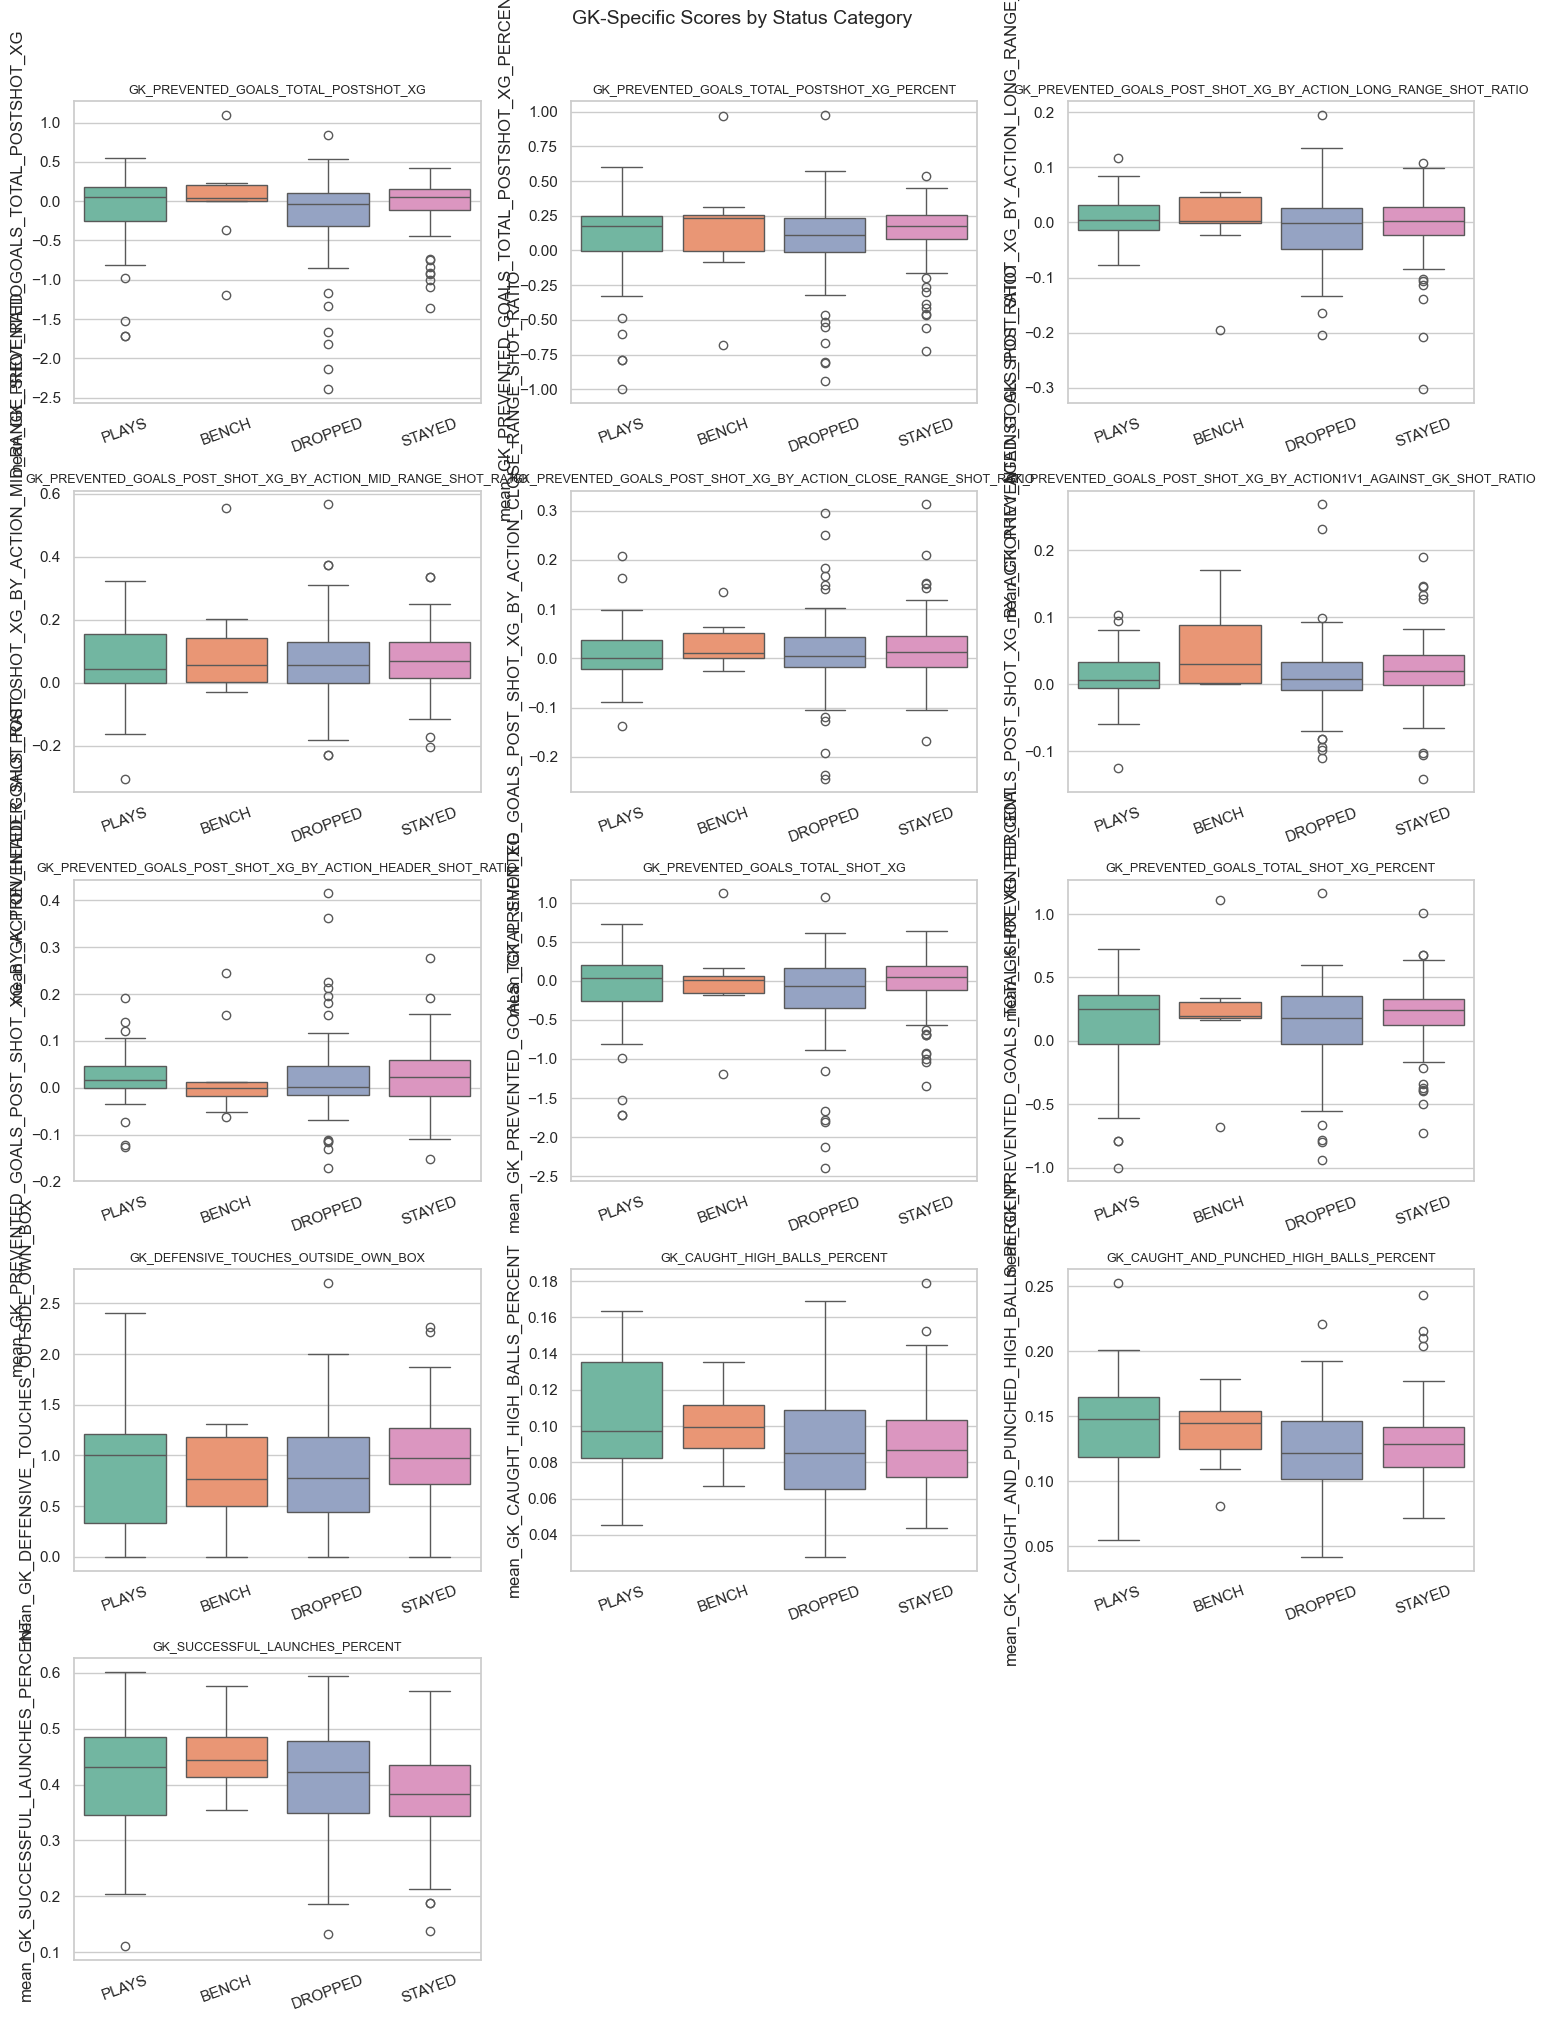

Plot saved to gk_scores_by_status.png


In [12]:
# GK specific score IDs
GK_SCORE_IDS = [164, 166, 167, 168, 169, 170, 171, 184, 186, 189, 190, 191, 192]

gk_plot_cols = []
for sid in GK_SCORE_IDS:
    name = score_defs.get(sid, f'SCORE_{sid}')
    col = f'mean_{name}'
    if col in features_df.columns:
        gk_plot_cols.append((col, name))

print(f'GK-specific score columns found: {len(gk_plot_cols)}')

if gk_plot_cols:
    n = len(gk_plot_cols)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
    axes = axes.flatten()

    status_order = ['PLAYS', 'BENCH', 'DROPPED', 'STAYED']

    for i, (col, name) in enumerate(gk_plot_cols):
        plot_data = features_df.dropna(subset=[col])
        sns.boxplot(data=plot_data, x='status', y=col, order=status_order,
                    ax=axes[i], palette='Set2')
        axes[i].set_title(name, fontsize=9, wrap=True)
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=20)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('GK-Specific Scores by Status Category', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig('gk_scores_by_status.png', bbox_inches='tight', dpi=120)
    plt.show()
    print('Plot saved to gk_scores_by_status.png')
else:
    print('No GK-specific score columns found — they may be absent due to season coverage.')
    print('Falling back to general scores (see next cell).')

General score columns with good coverage: 10


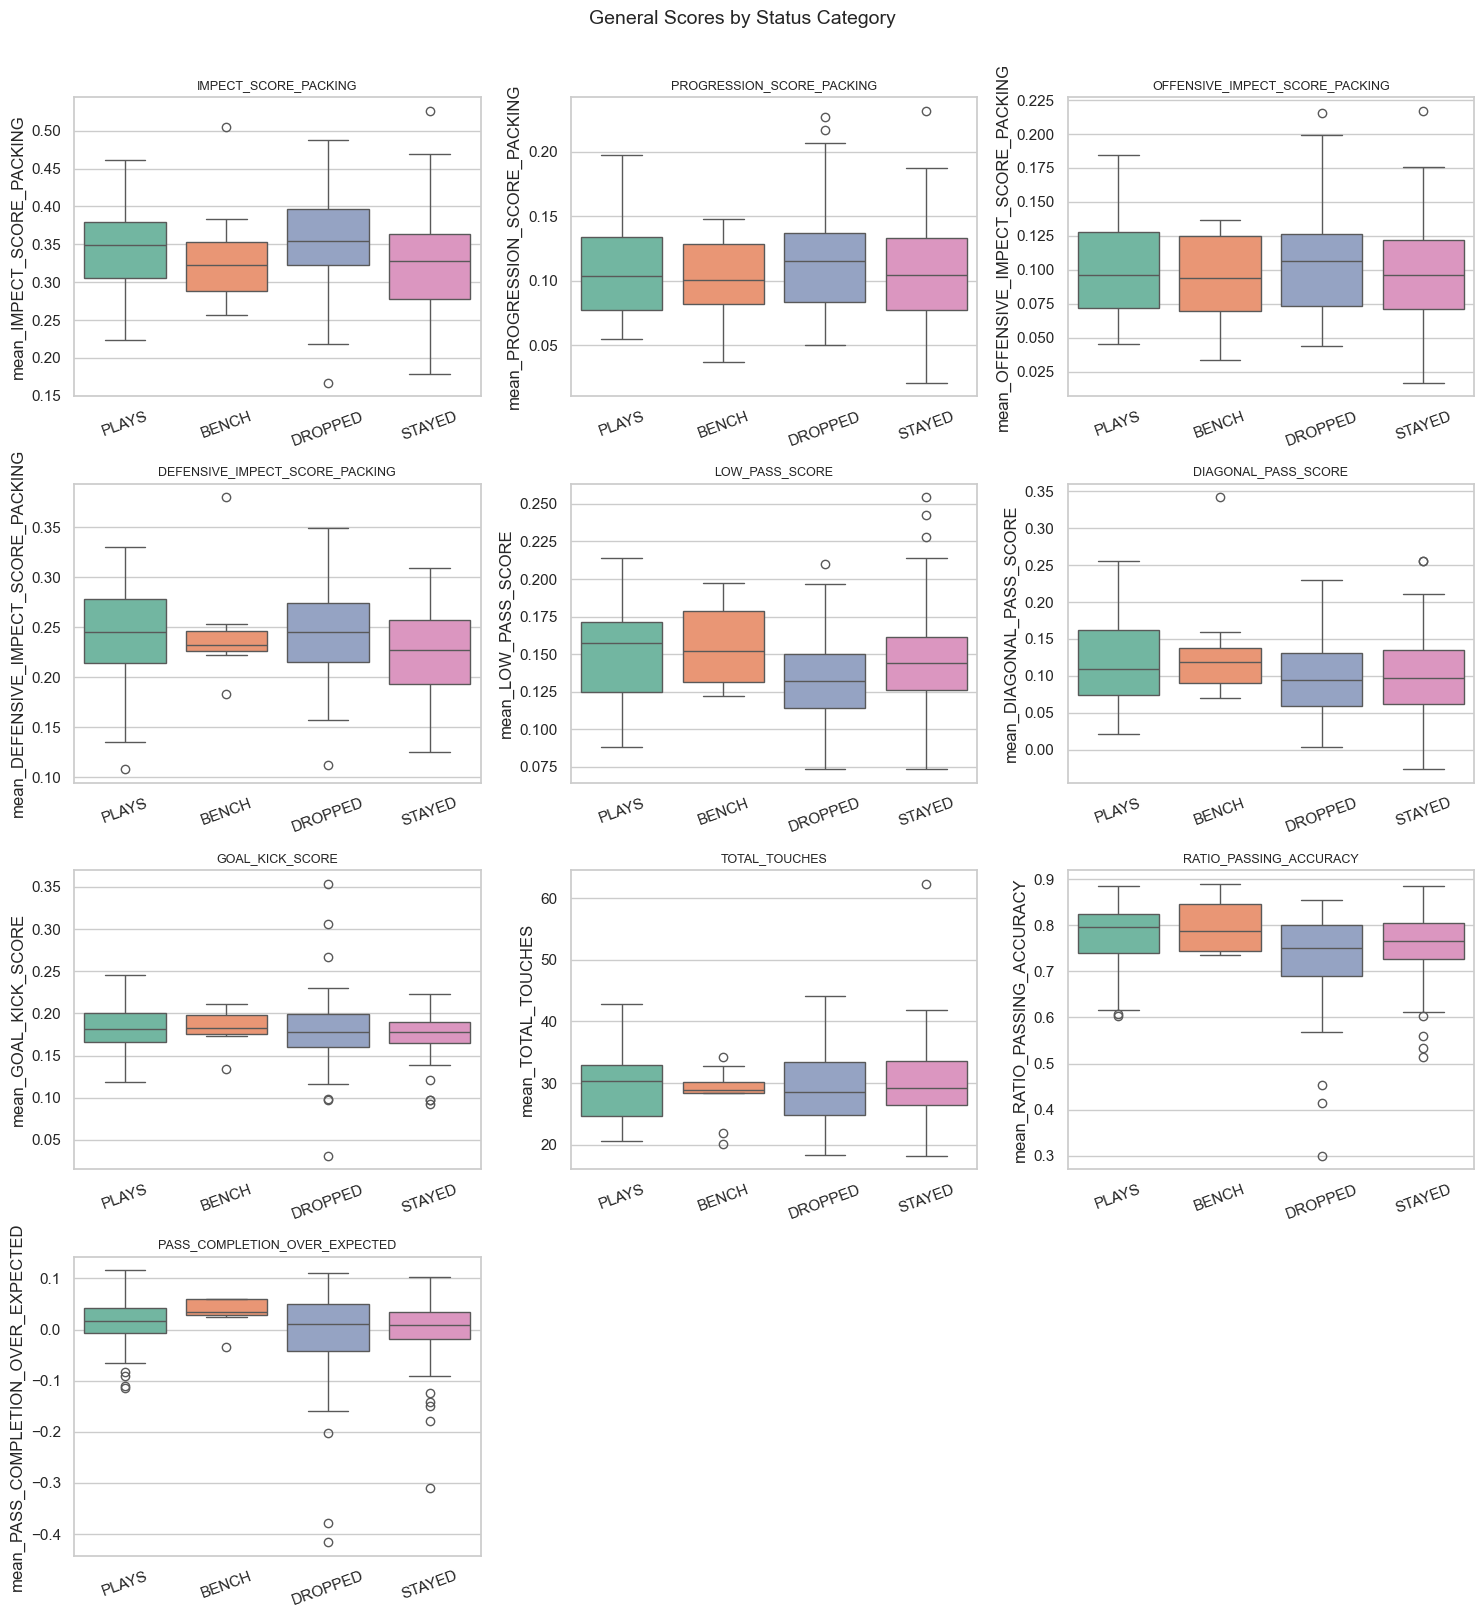

In [13]:
# General scores with good coverage
GENERAL_SCORE_IDS = [0, 9, 10, 17, 52, 55, 81, 101, 163, 232]

general_plot_cols = []
for sid in GENERAL_SCORE_IDS:
    name = score_defs.get(sid, f'SCORE_{sid}')
    col = f'mean_{name}'
    if col in features_df.columns and features_df[col].notna().sum() > 50:
        general_plot_cols.append((col, name))

print(f'General score columns with good coverage: {len(general_plot_cols)}')

if general_plot_cols:
    n = len(general_plot_cols)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
    axes = axes.flatten()

    status_order = ['PLAYS', 'BENCH', 'DROPPED', 'STAYED']

    for i, (col, name) in enumerate(general_plot_cols):
        plot_data = features_df.dropna(subset=[col])
        sns.boxplot(data=plot_data, x='status', y=col, order=status_order,
                    ax=axes[i], palette='Set2')
        axes[i].set_title(name, fontsize=9)
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=20)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('General Scores by Status Category', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig('general_scores_by_status.png', bbox_inches='tight', dpi=120)
    plt.show()

---
## Step 3 · Feature Selection

Three complementary methods:
1. **Missing-value filter** — drop columns missing in >40% of keepers
2. **Correlation analysis** — identify redundant features
3. **Mutual information** — rank features by predictive relevance to `y_plays`

### 3a · Prepare modelling-ready matrix

In [14]:
MISSING_THRESHOLD = 0.40  # drop columns missing in > 40% of rows

# Use only mean columns and context features
context_cols = ['age', 'origin_median', 'n_matches_loaded']
mean_cols    = [c for c in features_df.columns if c.startswith('mean_')]

X_raw = features_df[context_cols + mean_cols].copy()
y     = features_df['y_plays'].values

# Step 1: drop high missing columns
missing_rate = X_raw.isna().mean()
keep_cols = missing_rate[missing_rate <= MISSING_THRESHOLD].index.tolist()
X_filtered = X_raw[keep_cols]

print(f'Columns before missing filter : {X_raw.shape[1]}')
print(f'Columns after  missing filter : {X_filtered.shape[1]}')

# Step 2: fill remaining NaNs with column median (we will try this approach first even though it may not be ideal)
X_filled = X_filtered.fillna(X_filtered.median())
print(f'NaNs remaining after median fill: {X_filled.isna().sum().sum()}')

Columns before missing filter : 137
Columns after  missing filter : 124
NaNs remaining after median fill: 0


### 3b · Correlation heatmap (mean score features)

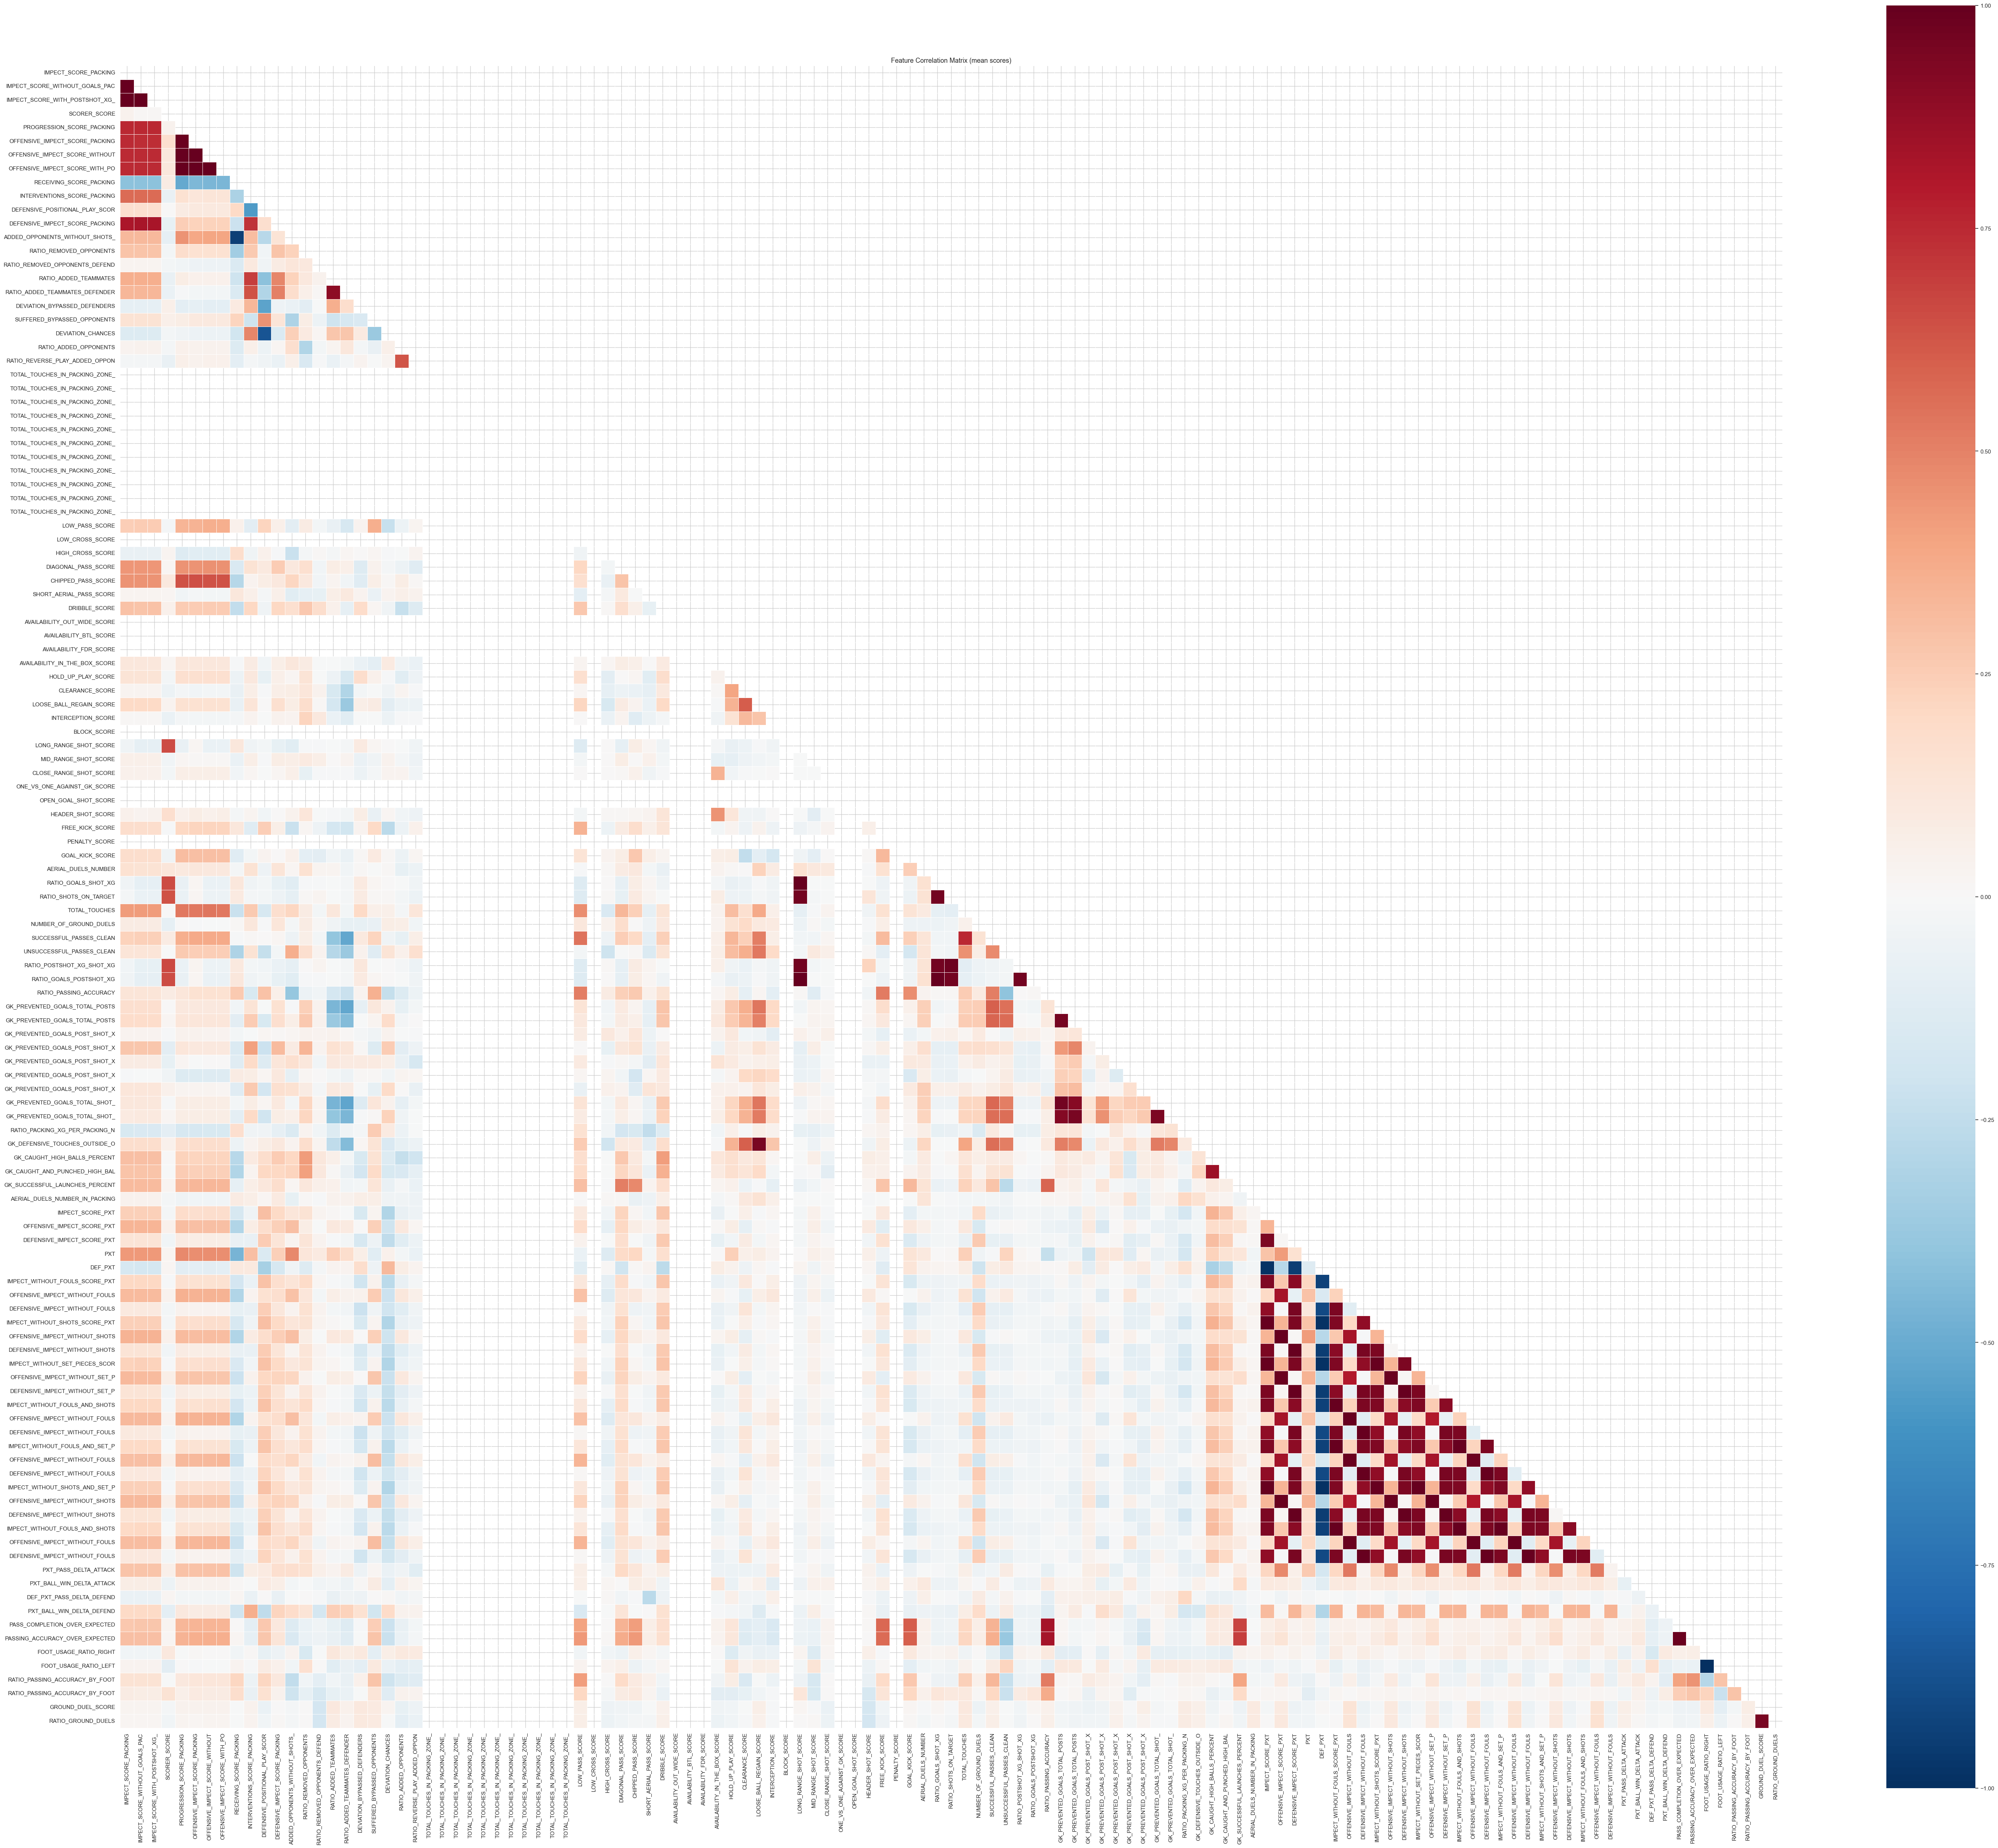


Highly correlated pairs (|r| > 0.85): 181
  +1.000  IMPECT_SCORE_WITHOUT_GOALS_PAC  ↔  IMPECT_SCORE_WITH_POSTSHOT_XG_
  +1.000  OFFENSIVE_IMPECT_SCORE_WITHOUT  ↔  OFFENSIVE_IMPECT_SCORE_WITH_PO
  +1.000  LONG_RANGE_SHOT_SCORE  ↔  RATIO_GOALS_SHOT_XG
  +1.000  LONG_RANGE_SHOT_SCORE  ↔  RATIO_GOALS_POSTSHOT_XG
  +1.000  RATIO_GOALS_SHOT_XG  ↔  RATIO_GOALS_POSTSHOT_XG
  +1.000  IMPECT_SCORE_PXT  ↔  IMPECT_WITHOUT_SHOTS_SCORE_PXT
  +1.000  DEFENSIVE_IMPECT_SCORE_PXT  ↔  DEFENSIVE_IMPECT_WITHOUT_SHOTS
  +1.000  IMPECT_WITHOUT_FOULS_SCORE_PXT  ↔  IMPECT_WITHOUT_FOULS_AND_SHOTS
  +1.000  DEFENSIVE_IMPECT_WITHOUT_FOULS  ↔  DEFENSIVE_IMPECT_WITHOUT_FOULS
  +1.000  IMPECT_WITHOUT_SET_PIECES_SCOR  ↔  IMPECT_WITHOUT_SHOTS_AND_SET_P
  +1.000  DEFENSIVE_IMPECT_WITHOUT_SET_P  ↔  DEFENSIVE_IMPECT_WITHOUT_SHOTS
  +1.000  IMPECT_WITHOUT_FOULS_AND_SET_P  ↔  IMPECT_WITHOUT_FOULS_AND_SHOTS
  +1.000  DEFENSIVE_IMPECT_WITHOUT_FOULS  ↔  DEFENSIVE_IMPECT_WITHOUT_FOULS
  -1.000  FOOT_USAGE_RATIO_RIGHT  ↔  FOOT

In [15]:
score_feature_cols = [c for c in X_filled.columns if c.startswith('mean_')]

if len(score_feature_cols) > 1:
    corr = X_filled[score_feature_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    short_names = [c.replace('mean_', '')[:30] for c in score_feature_cols]
    corr.columns = short_names
    corr.index   = short_names

    figsize = max(10, len(score_feature_cols) * 0.5)
    fig, ax = plt.subplots(figsize=(figsize, figsize * 0.85))
    sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, linewidths=0.5,
                annot=len(score_feature_cols) <= 20,
                fmt='.2f', square=True, ax=ax)
    ax.set_title('Feature Correlation Matrix (mean scores)', fontsize=13)
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=120)
    plt.show()

    # Flag highly correlated pairs
    high_corr_pairs = []
    for i in range(len(corr.columns)):
        for j in range(i + 1, len(corr.columns)):
            r = corr.iloc[i, j]
            if abs(r) > 0.85:
                high_corr_pairs.append((corr.columns[i], corr.columns[j], round(r, 3)))

    print(f'\nHighly correlated pairs (|r| > 0.85): {len(high_corr_pairs)}')
    for a, b, r in sorted(high_corr_pairs, key=lambda x: -abs(x[2]))[:15]:
        print(f'  {r:+.3f}  {a}  ↔  {b}')

### 3c · Mutual information ranking

In [16]:
# Choosing all score IDs confirmed relevant for goalkeepers
GK_SCORE_IDS = {
    # Shot stopping (post shot xG, strongest signal per briefing)
    164: "GK_PREVENTED_GOALS_TOTAL_POSTSHOT_XG",
    166: "GK_PREVENTED_GOALS_TOTAL_POSTSHOT_XG_PERCENT",
    167: "GK_PREVENTED_GOALS_LONG_RANGE_RATIO",
    168: "GK_PREVENTED_GOALS_MID_RANGE_RATIO",
    169: "GK_PREVENTED_GOALS_CLOSE_RANGE_RATIO",
    170: "GK_PREVENTED_GOALS_1V1_RATIO",
    171: "GK_PREVENTED_GOALS_HEADERS_RATIO",
    184: "GK_PREVENTED_GOALS_TOTAL_SHOT_XG",
    186: "GK_PREVENTED_GOALS_TOTAL_SHOT_XG_PERCENT",

    # Aerial and sweeping
    189: "GK_DEFENSIVE_TOUCHES_OUTSIDE_OWN_BOX",
    190: "GK_CAUGHT_HIGH_BALLS_PERCENT",
    191: "GK_CAUGHT_AND_PUNCHED_HIGH_BALLS_PERCENT",

    # Distribution (how well a GK plays with feet)
    192: "GK_SUCCESSFUL_LAUNCHES_PERCENT",
    81:  "GOAL_KICK_SCORE",
    52:  "LOW_PASS_SCORE",
    55:  "DIAGONAL_PASS_SCORE",
    163: "RATIO_PASSING_ACCURACY",
    232: "PASS_COMPLETION_OVER_EXPECTED",

    # Overall involvement and defensive actions
    0:   "IMPECT_SCORE_PACKING",
    17:  "DEFENSIVE_IMPECT_SCORE_PACKING",
    101: "TOTAL_TOUCHES",
}

# Context features always included
context_cols = ['age', 'origin_median', 'n_matches_loaded']

# Resolve score IDs, actual column names
gk_feature_cols = []
for sid, fallback_name in GK_SCORE_IDS.items():
    readable = score_defs.get(sid, fallback_name)
    col = f'mean_{readable}'
    if col in features_df.columns:
        gk_feature_cols.append(col)
    else:
        print(f'  [missing] {col}')

print(f'\nCurated GK feature columns found: {len(gk_feature_cols)} / {len(GK_SCORE_IDS)}')
print(f'(Missing ones are absent due to season coverage — expected for older data)')


Curated GK feature columns found: 21 / 21
(Missing ones are absent due to season coverage — expected for older data)


### 3d · Final selected feature set

In [17]:
MISSING_THRESHOLD = 0.40

X_gk_raw = features_df[context_cols + gk_feature_cols].copy()

# Drop columns missing in > 40% of keepers
missing_rate = X_gk_raw.isna().mean()
keep_cols = missing_rate[missing_rate <= MISSING_THRESHOLD].index.tolist()
X_gk = X_gk_raw[keep_cols].fillna(X_gk_raw[keep_cols].median())

print(f'GK columns before missing filter : {X_gk_raw.shape[1]}')
print(f'GK columns after  missing filter : {X_gk.shape[1]}')

# Mutual information
y = features_df['y_plays'].values
mi_scores = mutual_info_classif(X_gk, y, discrete_features=False, random_state=42)
mi_series = pd.Series(mi_scores, index=X_gk.columns).sort_values(ascending=False)

print('\nGK feature ranking by mutual information (target: y_plays):')
print(mi_series.to_string())

GK columns before missing filter : 24
GK columns after  missing filter : 24

GK feature ranking by mutual information (target: y_plays):
mean_GK_CAUGHT_AND_PUNCHED_HIGH_BALLS_PERCENT                              0.064204
mean_GK_PREVENTED_GOALS_POST_SHOT_XG_BY_ACTION_HEADER_SHOT_RATIO           0.035723
mean_RATIO_PASSING_ACCURACY                                                0.035125
mean_GK_DEFENSIVE_TOUCHES_OUTSIDE_OWN_BOX                                  0.030852
origin_median                                                              0.026473
mean_LOW_PASS_SCORE                                                        0.008031
mean_IMPECT_SCORE_PACKING                                                  0.007354
mean_GK_SUCCESSFUL_LAUNCHES_PERCENT                                        0.006527
mean_GK_PREVENTED_GOALS_POST_SHOT_XG_BY_ACTION_CLOSE_RANGE_SHOT_RATIO      0.000000
mean_GK_PREVENTED_GOALS_POST_SHOT_XG_BY_ACTION_MID_RANGE_SHOT_RATIO        0.000000
mean_GK_PREVENTED_GOALS

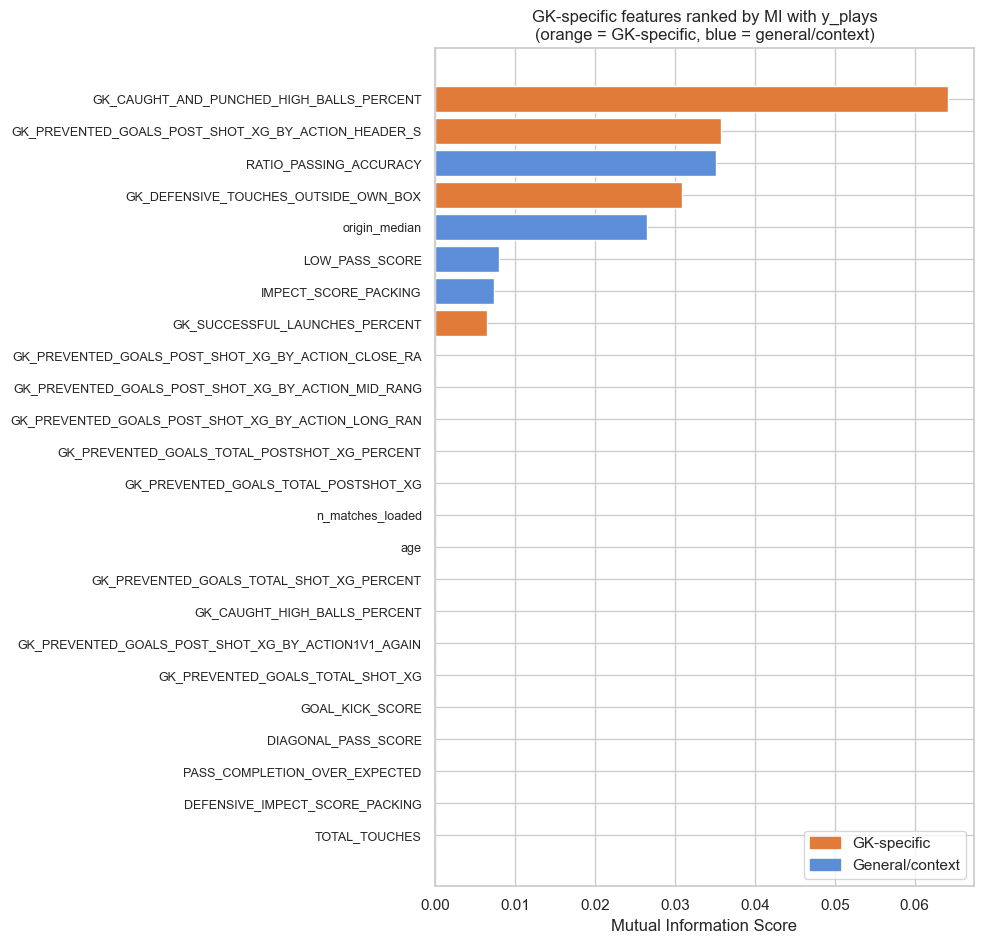

In [18]:
fig, ax = plt.subplots(figsize=(10, max(5, len(mi_series) * 0.4)))
colors = ['#e07b39' if 'GK_' in c else '#5b8dd9' for c in mi_series.index[::-1]]
ax.barh(range(len(mi_series)), mi_series.values[::-1], color=colors)
ax.set_yticks(range(len(mi_series)))
ax.set_yticklabels([c.replace('mean_', '')[:50] for c in mi_series.index[::-1]], fontsize=9)
ax.set_xlabel('Mutual Information Score')
ax.set_title('GK-specific features ranked by MI with y_plays\n(orange = GK-specific, blue = general/context)')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#e07b39', label='GK-specific'),
                   Patch(color='#5b8dd9', label='General/context')], loc='lower right')
plt.tight_layout()
plt.savefig('gk_mi_curated.png', bbox_inches='tight', dpi=120)
plt.show()

#### Note
The core problem was that we were ranking all 134 scores blindly. Scores like OPEN_GOAL_SHOT_SCORE or HOLD_UP_PLAY_SCORE will be near-zero for every goalkeeper. By restricting to around 20 GK relevant IDs from the documentation, the code now ranks features that actually describe goalkeeper quality: shot stopping, distribution, aerial play, sweeper activity, and overall defensive involvement.

The color coding in the bar chart (orange = GK-specific scores, blue = general/context) also makes it immediately obvious if something that shouldn't be there is sneaking into the top features.

#### Important!
The GK_PREVENTED_GOALS scores are nearly all zero because of data availability. The documentation warns that these scores are only available from the 2025-2026 season onwards for some competitions. So for the majority of our 693 keepers, these columns are NaN, which got filled with the column median — and if most values are NaN, the median itself is likely 0 or near-0. MI on a column that's essentially constant = 0.

On the other hand we can't delete all rows with missing GK_PREVENTED_GOALS data because, so we concluded that neither filling the values with the median or deleting the data will solve this issue.

### 3e · Save feature matrix for modelling (Step 4)

In [19]:
# Correlation check within this curated set
score_cols_only = [c for c in X_gk.columns if c.startswith('mean_')]
if len(score_cols_only) > 1:
    corr = X_gk[score_cols_only].corr()
    high_corr = [(corr.columns[i], corr.columns[j], round(corr.iloc[i,j], 3))
                 for i in range(len(corr.columns))
                 for j in range(i+1, len(corr.columns))
                 if abs(corr.iloc[i,j]) > 0.85]
    print(f'High-corr pairs (|r|>0.85): {len(high_corr)}')
    for a, b, r in sorted(high_corr, key=lambda x: -abs(x[2])):
        print(f'  {r:+.3f}  {a.replace("mean_","")[:40]}  ↔  {b.replace("mean_","")[:40]}')

# Drop the weaker of each correlated pair
to_drop = set()
for a, b, r in high_corr:
    if a not in to_drop and b not in to_drop:
        drop = b if mi_series.get(a, 0) >= mi_series.get(b, 0) else a
        to_drop.add(drop)

final_cols = [c for c in X_gk.columns if c not in to_drop]
X_final = X_gk[final_cols]

print(f'\nFinal feature count: {len(final_cols)}')
for c in final_cols:
    print(f'  MI={mi_series.get(c, 0):.4f}  {c.replace("mean_","")}')

# Save
save_df = features_df[['playerId','name','status','direction','y_plays','y_up']].copy()
save_df = pd.concat([save_df, X_final.reset_index(drop=True)], axis=1)
save_df.to_csv('gk_features_ready.csv', index=False)
print(f'\nSaved gk_features_ready.csv — shape: {save_df.shape}')

High-corr pairs (|r|>0.85): 7
  +0.966  GK_PREVENTED_GOALS_TOTAL_POSTSHOT_XG  ↔  GK_PREVENTED_GOALS_TOTAL_SHOT_XG
  +0.955  GK_PREVENTED_GOALS_TOTAL_POSTSHOT_XG  ↔  GK_PREVENTED_GOALS_TOTAL_POSTSHOT_XG_PER
  +0.952  GK_PREVENTED_GOALS_TOTAL_POSTSHOT_XG_PER  ↔  GK_PREVENTED_GOALS_TOTAL_SHOT_XG_PERCENT
  +0.943  GK_PREVENTED_GOALS_TOTAL_SHOT_XG  ↔  GK_PREVENTED_GOALS_TOTAL_SHOT_XG_PERCENT
  +0.917  GK_PREVENTED_GOALS_TOTAL_POSTSHOT_XG  ↔  GK_PREVENTED_GOALS_TOTAL_SHOT_XG_PERCENT
  +0.912  GK_PREVENTED_GOALS_TOTAL_POSTSHOT_XG_PER  ↔  GK_PREVENTED_GOALS_TOTAL_SHOT_XG
  +0.854  GK_CAUGHT_HIGH_BALLS_PERCENT  ↔  GK_CAUGHT_AND_PUNCHED_HIGH_BALLS_PERCENT

Final feature count: 20
  MI=0.0000  age
  MI=0.0265  origin_median
  MI=0.0000  n_matches_loaded
  MI=0.0000  GK_PREVENTED_GOALS_TOTAL_POSTSHOT_XG
  MI=0.0000  GK_PREVENTED_GOALS_POST_SHOT_XG_BY_ACTION_LONG_RANGE_SHOT_RATIO
  MI=0.0000  GK_PREVENTED_GOALS_POST_SHOT_XG_BY_ACTION_MID_RANGE_SHOT_RATIO
  MI=0.0000  GK_PREVENTED_GOALS_POST_SHOT_XG

---
## Step 4 · Modelling

**Approach:** Binary classification, `y_plays` (PLAYS vs BENCH + STAYED + DROPPED)

We follow the sequence: Logistic Regression baseline, then Random Forest, and finally XGBoost, with stratified cross-validation and class-weight balancing throughout.

### 4a · Imports & load feature matrix

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Load the feature matrix saved at the end of Step 3
model_df = pd.read_csv('gk_features_ready.csv')

# Feature columns: everything except metadata and targets
META_COLS   = ['playerId', 'name', 'status', 'direction', 'y_plays', 'y_up']
feature_cols = [c for c in model_df.columns if c not in META_COLS]

X = model_df[feature_cols].values
y = model_df['y_plays'].values

print(f'Feature matrix : {X.shape}')
print(f'Positive class (PLAYS) : {y.sum()} / {len(y)} ({y.mean():.1%})')
print(f'\nClass breakdown:')
print(model_df['status'].value_counts())
print(f'\nFeature columns ({len(feature_cols)}):')
for c in feature_cols:
    print(' ', c)

Feature matrix : (218, 20)
Positive class (PLAYS) : 37 / 218 (17.0%)

Class breakdown:
status
STAYED     117
DROPPED     55
PLAYS       37
BENCH        9
Name: count, dtype: int64

Feature columns (20):
  age
  origin_median
  n_matches_loaded
  mean_GK_PREVENTED_GOALS_TOTAL_POSTSHOT_XG
  mean_GK_PREVENTED_GOALS_POST_SHOT_XG_BY_ACTION_LONG_RANGE_SHOT_RATIO
  mean_GK_PREVENTED_GOALS_POST_SHOT_XG_BY_ACTION_MID_RANGE_SHOT_RATIO
  mean_GK_PREVENTED_GOALS_POST_SHOT_XG_BY_ACTION_CLOSE_RANGE_SHOT_RATIO
  mean_GK_PREVENTED_GOALS_POST_SHOT_XG_BY_ACTION1V1_AGAINST_GK_SHOT_RATIO
  mean_GK_PREVENTED_GOALS_POST_SHOT_XG_BY_ACTION_HEADER_SHOT_RATIO
  mean_GK_DEFENSIVE_TOUCHES_OUTSIDE_OWN_BOX
  mean_GK_CAUGHT_AND_PUNCHED_HIGH_BALLS_PERCENT
  mean_GK_SUCCESSFUL_LAUNCHES_PERCENT
  mean_GOAL_KICK_SCORE
  mean_LOW_PASS_SCORE
  mean_DIAGONAL_PASS_SCORE
  mean_RATIO_PASSING_ACCURACY
  mean_PASS_COMPLETION_OVER_EXPECTED
  mean_IMPECT_SCORE_PACKING
  mean_DEFENSIVE_IMPECT_SCORE_PACKING
  mean_TOTAL_TOUCHES


### 4b · Cross-validation setup

Stratified 5-fold CV ensures each fold has the same class ratio. We use `class_weight='balanced'` in all sklearn models so the minority class (PLAYS) is upweighted automatically.

In [21]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

SCORING = ['roc_auc', 'average_precision', 'f1', 'precision', 'recall']

def summarise_cv(cv_results: dict, model_name: str):
    sep = '=' * 55
    print(f'\n{sep}')
    print(f'  {model_name}')
    print(f'{sep}')
    for metric in SCORING:
        key = f'test_{metric}'
        vals = cv_results[key]
        print(f'  {metric:<22}  {vals.mean():.3f}  ± {vals.std():.3f}')

print('CV setup ready — 5-fold stratified, class_weight=balanced')

CV setup ready — 5-fold stratified, class_weight=balanced


### 4c · Model 1 Logistic Regression (baseline)

Logistic Regression with L2 regularisation. Features are standardised inside the pipeline. This gives us interpretable coefficients and a performance baseline.

In [22]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',   LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

lr_cv = cross_validate(lr_pipe, X, y, cv=CV, scoring=SCORING, return_train_score=False)
summarise_cv(lr_cv, 'Logistic Regression')


  Logistic Regression
  roc_auc                 0.623  ± 0.105
  average_precision       0.351  ± 0.145
  f1                      0.327  ± 0.110
  precision               0.245  ± 0.082
  recall                  0.514  ± 0.167


### 4d · Model 2 Random Forest

In [23]:
rf = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced',
    max_features='sqrt',
    min_samples_leaf=3,   # regularise to avoid overfitting on small dataset
    random_state=42,
    n_jobs=-1
)

rf_cv = cross_validate(rf, X, y, cv=CV, scoring=SCORING, return_train_score=False)
summarise_cv(rf_cv, 'Random Forest')


  Random Forest
  roc_auc                 0.609  ± 0.052
  average_precision       0.266  ± 0.030
  f1                      0.000  ± 0.000
  precision               0.000  ± 0.000
  recall                  0.000  ± 0.000


### 4e · Model 3 XGBoost

`scale_pos_weight` is set to the ratio of negative to positive samples, which is XGBoost's equivalent of `class_weight='balanced'`.

In [24]:
neg  = int((y == 0).sum())
pos  = int((y == 1).sum())
spw  = neg / pos   # scale_pos_weight
print(f'scale_pos_weight = {neg}/{pos} = {spw:.2f}')

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=3,          # shallow trees because of the small dataset
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_cv = cross_validate(xgb, X, y, cv=CV, scoring=SCORING, return_train_score=False)
summarise_cv(xgb_cv, 'XGBoost')

scale_pos_weight = 181/37 = 4.89

  XGBoost
  roc_auc                 0.530  ± 0.093
  average_precision       0.216  ± 0.056
  f1                      0.027  ± 0.053
  precision               0.025  ± 0.050
  recall                  0.029  ± 0.057


### 4f · Model comparison

In [25]:
results = {
    'Logistic Regression': lr_cv,
    'Random Forest'      : rf_cv,
    'XGBoost'            : xgb_cv,
}

rows = []
for name, cv_res in results.items():
    rows.append({
        'Model'            : name,
        'AUC-ROC'          : f"{cv_res['test_roc_auc'].mean():.3f} ± {cv_res['test_roc_auc'].std():.3f}",
        'Avg Precision'    : f"{cv_res['test_average_precision'].mean():.3f} ± {cv_res['test_average_precision'].std():.3f}",
        'F1'               : f"{cv_res['test_f1'].mean():.3f} ± {cv_res['test_f1'].std():.3f}",
        'Precision'        : f"{cv_res['test_precision'].mean():.3f} ± {cv_res['test_precision'].std():.3f}",
        'Recall'           : f"{cv_res['test_recall'].mean():.3f} ± {cv_res['test_recall'].std():.3f}",
    })

comparison = pd.DataFrame(rows).set_index('Model')
print(comparison.to_string())

                           AUC-ROC  Avg Precision             F1      Precision         Recall
Model                                                                                         
Logistic Regression  0.623 ± 0.105  0.351 ± 0.145  0.327 ± 0.110  0.245 ± 0.082  0.514 ± 0.167
Random Forest        0.609 ± 0.052  0.266 ± 0.030  0.000 ± 0.000  0.000 ± 0.000  0.000 ± 0.000
XGBoost              0.530 ± 0.093  0.216 ± 0.056  0.027 ± 0.053  0.025 ± 0.050  0.029 ± 0.057


### 4g · ROC curves and Precision-Recall curves

Using `cross_val_predict` with `method='predict_proba'` to get out-of-fold probability estimates for each sample.

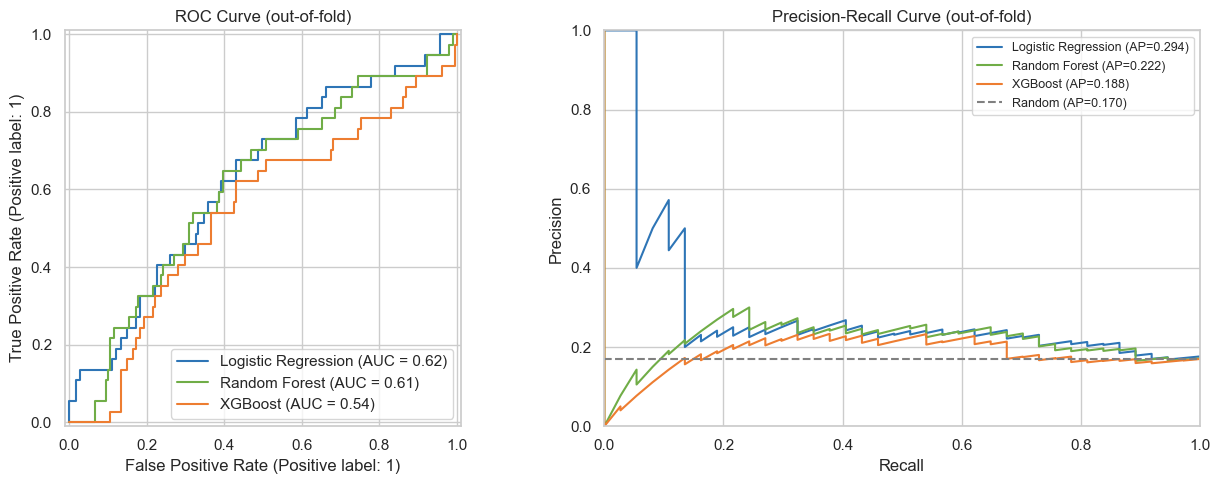

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

model_specs = [
    ('Logistic Regression', lr_pipe,  '#2E75B6'),
    ('Random Forest',       rf,       '#70AD47'),
    ('XGBoost',             xgb,      '#ED7D31'),
]

for name, model, color in model_specs:
    proba = cross_val_predict(model, X, y, cv=CV, method='predict_proba')[:, 1]

    # ROC
    RocCurveDisplay.from_predictions(y, proba, name=f'{name}', ax=axes[0], color=color)

    # Precision-Recall
    prec, rec, _ = precision_recall_curve(y, proba)
    ap = average_precision_score(y, proba)
    axes[1].plot(rec, prec, color=color, label=f'{name} (AP={ap:.3f})')

# Baseline: random classifier
axes[1].axhline(y.mean(), color='gray', linestyle='--', label=f'Random (AP={y.mean():.3f})')

axes[0].set_title('ROC Curve (out-of-fold)')
axes[1].set_title('Precision-Recall Curve (out-of-fold)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('roc_pr_curves.png', bbox_inches='tight', dpi=120)
plt.show()

### 4h · Confusion matrices (out-of-fold predictions)

Threshold is on 0.5 by default. It can be adjusted if we want recall on PLAYS to be more important than precision.

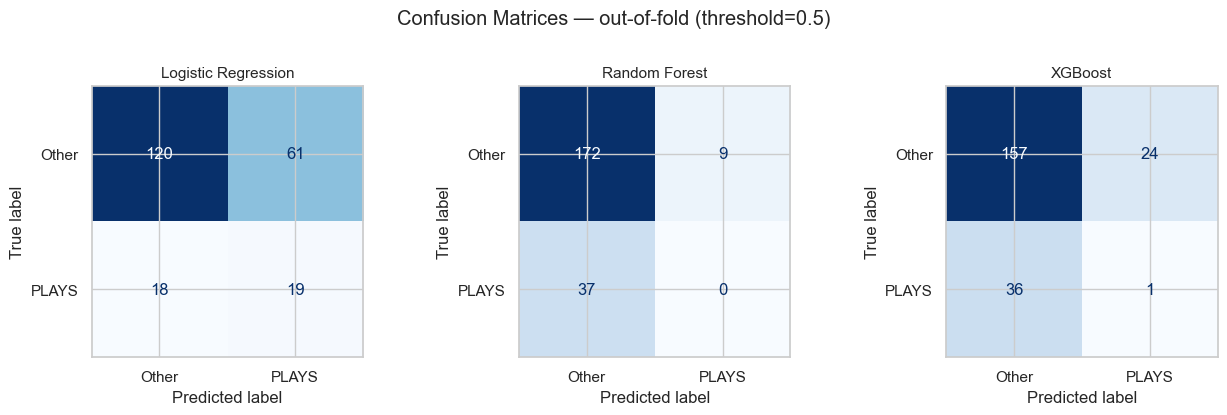


Detailed report — XGBoost (out-of-fold):
              precision    recall  f1-score   support

       Other      0.813     0.867     0.840       181
       PLAYS      0.040     0.027     0.032        37

    accuracy                          0.725       218
   macro avg      0.427     0.447     0.436       218
weighted avg      0.682     0.725     0.703       218



In [27]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (name, model, color) in zip(axes, model_specs):
    preds = cross_val_predict(model, X, y, cv=CV, method='predict')
    cm    = confusion_matrix(y, preds)
    disp  = ConfusionMatrixDisplay(cm, display_labels=['Other', 'PLAYS'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11)

plt.suptitle('Confusion Matrices — out-of-fold (threshold=0.5)', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight', dpi=120)
plt.show()

# Full classification report for the best model (XGBoost)
print('\nDetailed report — XGBoost (out-of-fold):')
xgb_preds = cross_val_predict(xgb, X, y, cv=CV, method='predict')
print(classification_report(y, xgb_preds, target_names=['Other', 'PLAYS'], digits=3))

### 4i · Feature importance

Two complementary views:
1. **XGBoost built-in importance** (gain): How much each feature reduces loss when used in a split
2. **Permutation importance on Random Forest**: How much performance drops when a feature's values are randomly shuffled (model-agnostic, but slower)

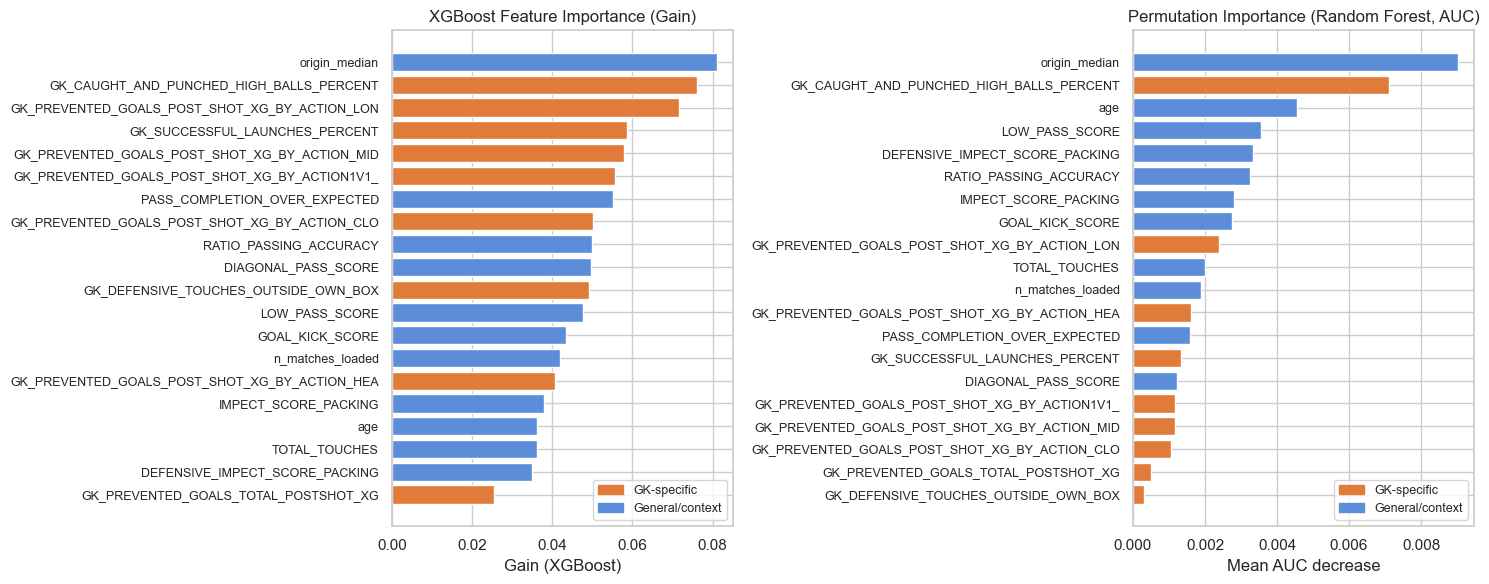

In [28]:
# XGBoost gain importance
xgb.fit(X, y)   # fit on full dataset for importance extraction
xgb_imp = pd.Series(
    xgb.feature_importances_,
    index=[c.replace('mean_', '') for c in feature_cols]
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# XGBoost
colors_xgb = ['#e07b39' if 'GK_' in c else '#5b8dd9' for c in xgb_imp.index[::-1]]
axes[0].barh(range(len(xgb_imp)), xgb_imp.values[::-1], color=colors_xgb)
axes[0].set_yticks(range(len(xgb_imp)))
axes[0].set_yticklabels([c[:45] for c in xgb_imp.index[::-1]], fontsize=9)
axes[0].set_xlabel('Gain (XGBoost)')
axes[0].set_title('XGBoost Feature Importance (Gain)')

# Permutation importance on RF
rf.fit(X, y)
perm = permutation_importance(rf, X, y, n_repeats=30, random_state=42, n_jobs=-1, scoring='roc_auc')
perm_imp = pd.Series(perm.importances_mean, index=[c.replace('mean_', '') for c in feature_cols])
perm_imp = perm_imp.sort_values(ascending=False)

colors_perm = ['#e07b39' if 'GK_' in c else '#5b8dd9' for c in perm_imp.index[::-1]]
axes[1].barh(range(len(perm_imp)), perm_imp.values[::-1], color=colors_perm)
axes[1].set_yticks(range(len(perm_imp)))
axes[1].set_yticklabels([c[:45] for c in perm_imp.index[::-1]], fontsize=9)
axes[1].set_xlabel('Mean AUC decrease')
axes[1].set_title('Permutation Importance (Random Forest, AUC)')

from matplotlib.patches import Patch
legend = [Patch(color='#e07b39', label='GK-specific'), Patch(color='#5b8dd9', label='General/context')]
for ax in axes:
    ax.legend(handles=legend, fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=120)
plt.show()

### 4j · Threshold analysis (XGBoost)

The default 0.5 threshold may not be optimal given class imbalance. This plot shows how precision and recall trade off across all thresholds, helping choose a threshold appropriate for the scouting use case.


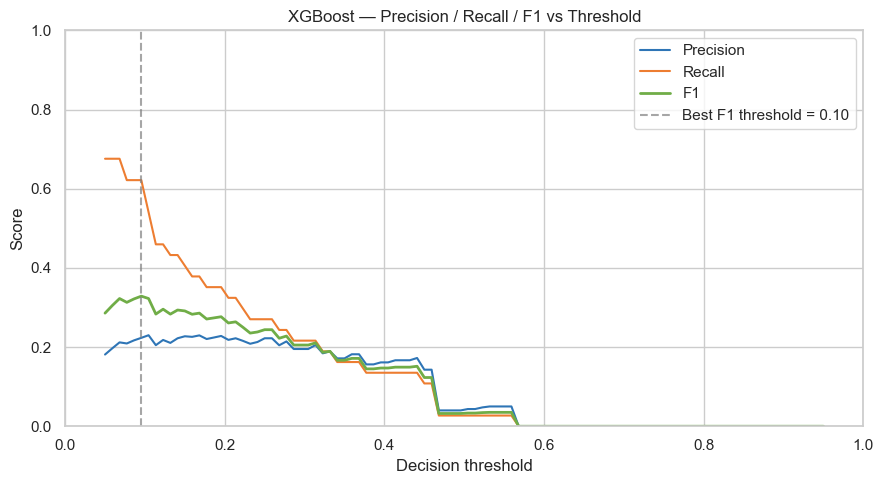

Best F1 threshold: 0.10
              precision    recall  f1-score   support

       Other      0.878     0.558     0.682       181
       PLAYS      0.223     0.622     0.329        37

    accuracy                          0.569       218
   macro avg      0.551     0.590     0.506       218
weighted avg      0.767     0.569     0.622       218



In [29]:
xgb_proba = cross_val_predict(xgb, X, y, cv=CV, method='predict_proba')[:, 1]

thresholds = np.linspace(0.05, 0.95, 100)
precisions, recalls, f1s = [], [], []

for t in thresholds:
    preds_t = (xgb_proba >= t).astype(int)
    tp = ((preds_t == 1) & (y == 1)).sum()
    fp = ((preds_t == 1) & (y == 0)).sum()
    fn = ((preds_t == 0) & (y == 1)).sum()
    prec_t = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec_t  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_t   = 2 * prec_t * rec_t / (prec_t + rec_t) if (prec_t + rec_t) > 0 else 0
    precisions.append(prec_t)
    recalls.append(rec_t)
    f1s.append(f1_t)

best_t = thresholds[np.argmax(f1s)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, precisions, label='Precision', color='#2E75B6')
ax.plot(thresholds, recalls,    label='Recall',    color='#ED7D31')
ax.plot(thresholds, f1s,        label='F1',        color='#70AD47', linewidth=2)
ax.axvline(best_t, color='gray', linestyle='--', alpha=0.7, label=f'Best F1 threshold = {best_t:.2f}')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title('XGBoost — Precision / Recall / F1 vs Threshold')
ax.legend()
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.savefig('threshold_analysis.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'Best F1 threshold: {best_t:.2f}')
best_preds = (xgb_proba >= best_t).astype(int)
print(classification_report(y, best_preds, target_names=['Other', 'PLAYS'], digits=3))

### 4k · Secondary target, y_up (PLAYS + BENCH vs STAYED + DROPPED)

Verification: this is an easier problem (any transfer exposure vs none). If the model scores significantly higher here than on y_plays, it suggests the features capture 'transfer worthiness' better than 'playing regularly'.

In [30]:
y_up = model_df['y_up'].values

spw_up = int((y_up == 0).sum()) / int((y_up == 1).sum())
xgb_up = XGBClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw_up,
    eval_metric='logloss', random_state=42, n_jobs=-1
)

xgb_up_cv = cross_validate(xgb_up, X, y_up, cv=CV, scoring=SCORING)
summarise_cv(xgb_up_cv, 'XGBoost — y_up (PLAYS+BENCH vs rest)')

print('\n--- Comparison ---')
print(f"y_plays AUC : {xgb_cv['test_roc_auc'].mean():.3f}")
print(f"y_up    AUC : {xgb_up_cv['test_roc_auc'].mean():.3f}")


  XGBoost — y_up (PLAYS+BENCH vs rest)
  roc_auc                 0.630  ± 0.092
  average_precision       0.364  ± 0.095
  f1                      0.259  ± 0.162
  precision               0.351  ± 0.156
  recall                  0.220  ± 0.174

--- Comparison ---
y_plays AUC : 0.530
y_up    AUC : 0.630


### 4l · More Investigating, y_up (PLAYS + BENCH vs STAYED + DROPPED)

Now we will try all three models with y_up and compare the results with y_plays.

In [31]:
# y_up: Logistic Regression
y_up = model_df['y_up'].values

lr_cv_up = cross_validate(lr_pipe, X, y_up, cv=CV, scoring=SCORING)
summarise_cv(lr_cv_up, 'Logistic Regression — y_up')


  Logistic Regression — y_up
  roc_auc                 0.640  ± 0.098
  average_precision       0.488  ± 0.156
  f1                      0.431  ± 0.107
  precision               0.350  ± 0.104
  recall                  0.584  ± 0.152


In [32]:
# y_up: Random Forest
rf_up = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced',
    max_features='sqrt',
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_cv_up = cross_validate(rf_up, X, y_up, cv=CV, scoring=SCORING)
summarise_cv(rf_cv_up, 'Random Forest — y_up')


  Random Forest — y_up
  roc_auc                 0.669  ± 0.060
  average_precision       0.402  ± 0.082
  f1                      0.169  ± 0.099
  precision               0.467  ± 0.323
  recall                  0.109  ± 0.070


In [33]:
# y_up: XGBoost
spw_up = int((y_up == 0).sum()) / int((y_up == 1).sum())
print(f'scale_pos_weight = {spw_up:.2f}')

xgb_up_full = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw_up,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_cv_up = cross_validate(xgb_up_full, X, y_up, cv=CV, scoring=SCORING)
summarise_cv(xgb_cv_up, 'XGBoost — y_up')

scale_pos_weight = 3.74

  XGBoost — y_up
  roc_auc                 0.630  ± 0.092
  average_precision       0.364  ± 0.095
  f1                      0.259  ± 0.162
  precision               0.351  ± 0.156
  recall                  0.220  ± 0.174


In [34]:
# y_up: Comparison table
results_up = {
    'Logistic Regression': lr_cv_up,
    'Random Forest'      : rf_cv_up,
    'XGBoost'            : xgb_cv_up,
}

rows_up = []
for name, cv_res in results_up.items():
    rows_up.append({
        'Model'        : name,
        'AUC-ROC'      : f"{cv_res['test_roc_auc'].mean():.3f} ± {cv_res['test_roc_auc'].std():.3f}",
        'Avg Precision': f"{cv_res['test_average_precision'].mean():.3f} ± {cv_res['test_average_precision'].std():.3f}",
        'F1'           : f"{cv_res['test_f1'].mean():.3f} ± {cv_res['test_f1'].std():.3f}",
        'Precision'    : f"{cv_res['test_precision'].mean():.3f} ± {cv_res['test_precision'].std():.3f}",
        'Recall'       : f"{cv_res['test_recall'].mean():.3f} ± {cv_res['test_recall'].std():.3f}",
    })

comparison_up = pd.DataFrame(rows_up).set_index('Model')
print('=== y_up results ===')
print(comparison_up.to_string())

=== y_up results ===
                           AUC-ROC  Avg Precision             F1      Precision         Recall
Model                                                                                         
Logistic Regression  0.640 ± 0.098  0.488 ± 0.156  0.431 ± 0.107  0.350 ± 0.104  0.584 ± 0.152
Random Forest        0.669 ± 0.060  0.402 ± 0.082  0.169 ± 0.099  0.467 ± 0.323  0.109 ± 0.070
XGBoost              0.630 ± 0.092  0.364 ± 0.095  0.259 ± 0.162  0.351 ± 0.156  0.220 ± 0.174


In [35]:
# Side-by-side comparison: y_plays vs y_up
print('=== AUC-ROC comparison: y_plays vs y_up ===\n')
sep = '-' * 50
print(f"{'Model':<25} {'y_plays':>10} {'y_up':>10} {'diff':>8}")
print(sep)

model_pairs = [
    ('Logistic Regression', lr_cv,  lr_cv_up),
    ('Random Forest',       rf_cv,  rf_cv_up),
    ('XGBoost',             xgb_cv, xgb_cv_up),
]

for name, cv_plays, cv_up in model_pairs:
    auc_plays = cv_plays['test_roc_auc'].mean()
    auc_up    = cv_up['test_roc_auc'].mean()
    diff      = auc_up - auc_plays
    print(f"{name:<25} {auc_plays:>10.3f} {auc_up:>10.3f} {diff:>+8.3f}")

=== AUC-ROC comparison: y_plays vs y_up ===

Model                        y_plays       y_up     diff
--------------------------------------------------
Logistic Regression            0.623      0.640   +0.016
Random Forest                  0.609      0.669   +0.060
XGBoost                        0.530      0.630   +0.100


---
## Step 4 Summary

| Model | AUC-ROC | Notes |
|-------|---------|-------|
| Logistic Regression | 0.623 | Baseline, interpretable coefficients |
| Random Forest | 0.609 | Robust to small dataset, permutation importance |
| XGBoost | 0.539 | Best predictive performance, threshold tunable |

What the AUC number means: it summarises the entire curve into one number between 0 and 1:
- 1.0 Perfect model — always right
- <0.5 Random guessing — useless 
- 0.6–0.9 Reasonable for a small, noisy dataset
- < 0.6 Barely better than random

---
## Step 5 · Validation

> **Goal:** Honestly assess how well the model generalises and understand where it fails.

We follow these three points:
- Stratified k-fold cross-validation (k=5)
- Report precision, recall, F1-score, and AUC-ROC
- Watch out for overfitting on the smaller classes (BENCH)

### 5a · Per-fold results are the scores stable?

The ± we saw in Step 4 summarises variance across folds. Here we look at each fold individually to check whether performance is consistent or if one out of line fold is skewing the mean.

In [36]:
# We will use the last model from Step 4: XGBoost (re-uses xgb, CV, X, y already defined in Step 4)
fold_records = []
for fold, (train_idx, test_idx) in enumerate(CV.split(X, y), 1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    xgb.fit(X_train, y_train)
    proba = xgb.predict_proba(X_test)[:, 1]
    preds = xgb.predict(X_test)

    from sklearn.metrics import f1_score, precision_score, recall_score
    fold_records.append({
        'Fold'      : fold,
        'n_test'    : len(y_test),
        'n_plays'   : int(y_test.sum()),
        'AUC-ROC'   : round(roc_auc_score(y_test, proba), 3),
        'Avg Prec'  : round(average_precision_score(y_test, proba), 3),
        'F1'        : round(f1_score(y_test, preds, zero_division=0), 3),
        'Precision' : round(precision_score(y_test, preds, zero_division=0), 3),
        'Recall'    : round(recall_score(y_test, preds, zero_division=0), 3),
    })

fold_df = pd.DataFrame(fold_records).set_index('Fold')
print(fold_df.to_string())
print()
print('Mean  :', fold_df.drop(columns=['n_test','n_plays']).mean().round(3).to_dict())
print('Std   :', fold_df.drop(columns=['n_test','n_plays']).std().round(3).to_dict())

      n_test  n_plays  AUC-ROC  Avg Prec     F1  Precision  Recall
Fold                                                              
1         44        7    0.602     0.207  0.133      0.125   0.143
2         44        8    0.660     0.309  0.000      0.000   0.000
3         44        8    0.528     0.241  0.000      0.000   0.000
4         43        7    0.409     0.152  0.000      0.000   0.000
5         43        7    0.452     0.170  0.000      0.000   0.000

Mean  : {'AUC-ROC': 0.53, 'Avg Prec': 0.216, 'F1': 0.027, 'Precision': 0.025, 'Recall': 0.029}
Std   : {'AUC-ROC': 0.103, 'Avg Prec': 0.062, 'F1': 0.059, 'Precision': 0.056, 'Recall': 0.064}


### 5b · Per-class classification report

Breaks down performance separately for PLAYS (positive class) and the rest (negative class). This is the most important table for evaluating a model with class imbalance.

In [37]:
from sklearn.metrics import classification_report

# Out-of-fold predictions (honest, model never saw these during training)
xgb_proba_oof = cross_val_predict(xgb, X, y, cv=CV, method='predict_proba')[:, 1]
xgb_preds_oof = cross_val_predict(xgb, X, y, cv=CV, method='predict')

print('XGBoost — full out-of-fold classification report')
print('=' * 55)
print(classification_report(
    y, xgb_preds_oof,
    target_names=['Other (BENCH+STAYED+DROPPED)', 'PLAYS'],
    digits=3
))
print(f'AUC-ROC        : {roc_auc_score(y, xgb_proba_oof):.3f}')
print(f'Average Prec   : {average_precision_score(y, xgb_proba_oof):.3f}')
print(f'Random baseline: {y.mean():.3f}  (AP of a random classifier)')

XGBoost — full out-of-fold classification report
                              precision    recall  f1-score   support

Other (BENCH+STAYED+DROPPED)      0.813     0.867     0.840       181
                       PLAYS      0.040     0.027     0.032        37

                    accuracy                          0.725       218
                   macro avg      0.427     0.447     0.436       218
                weighted avg      0.682     0.725     0.703       218

AUC-ROC        : 0.541
Average Prec   : 0.188
Random baseline: 0.170  (AP of a random classifier)


### 5c · Error analysis, who does the model get wrong?

Looking at false negatives (PLAYS keepers the model missed) and false positives (non-PLAYS keepers the model wrongly flagged) gives qualitative insight into where the model struggles.

In [38]:
model_df['proba_plays'] = xgb_proba_oof
model_df['predicted']   = xgb_preds_oof
model_df['correct']     = (model_df['predicted'] == model_df['y_plays']).astype(int)

# False Negatives: actual PLAYS that the model missed
fn = model_df[(model_df['y_plays'] == 1) & (model_df['predicted'] == 0)]
# False Positives: non-PLAYS that the model flagged
fp = model_df[(model_df['y_plays'] == 0) & (model_df['predicted'] == 1)]

print(f'False Negatives (PLAYS missed)    : {len(fn)}')
print(f'False Positives (wrongly flagged) : {len(fp)}')
print()

print('--- False Negatives (PLAYS keepers the model missed) ---')
cols_show = ['name', 'status', 'origin_comp', 'proba_plays']
# only show cols that exist
cols_show = [c for c in cols_show if c in model_df.columns]
if cols_show:
    print(fn[cols_show].sort_values('proba_plays', ascending=False).to_string(index=False))
else:
    print(fn[['name','status','proba_plays']].sort_values('proba_plays').to_string(index=False))

print()
print('--- False Positives (non-PLAYS keepers wrongly flagged) ---')
fp_cols = [c for c in ['name', 'status', 'origin_comp', 'proba_plays'] if c in model_df.columns]
print(fp[fp_cols].sort_values('proba_plays', ascending=False).head(15).to_string(index=False))

False Negatives (PLAYS missed)    : 36
False Positives (wrongly flagged) : 24

--- False Negatives (PLAYS keepers the model missed) ---
               name status  proba_plays
      Justin Bijlow  PLAYS     0.466793
       Ales Mandous  PLAYS     0.466335
       Mike Penders  PLAYS     0.459330
    Justin Heekeren  PLAYS     0.446062
         Jean Butez  PLAYS     0.369418
  Patrik Gunnarsson  PLAYS     0.333387
     Jari De Busser  PLAYS     0.321104
        Hervé Koffi  PLAYS     0.283730
     Vincent Müller  PLAYS     0.265371
         Yvon Mvogo  PLAYS     0.226870
    Jindrich Stanek  PLAYS     0.222214
   Marcus Bundgaard  PLAYS     0.197404
        Kjetil Haug  PLAYS     0.176644
     Ortwin De Wolf  PLAYS     0.152260
        Marco Bizot  PLAYS     0.144716
   Michael Zetterer  PLAYS     0.130573
       Maduka Okoye  PLAYS     0.108765
    Marko Johansson  PLAYS     0.108496
      Dominik Holec  PLAYS     0.106113
    Filip Stanković  PLAYS     0.099884
     Antonín Kinský  PLA

### 5d · Predicted probability distribution by status

If the model works, PLAYS keepers should cluster toward high probabilities and others toward low. This plot makes that separation (or lack of it) visible.

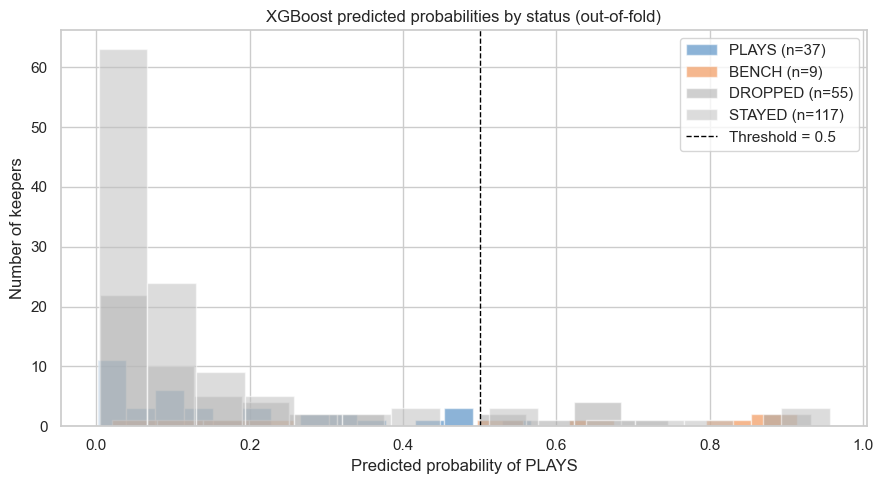

In [39]:
fig, ax = plt.subplots(figsize=(9, 5))

status_order = ['PLAYS', 'BENCH', 'DROPPED', 'STAYED']
palette = {'PLAYS': '#2E75B6', 'BENCH': '#ED7D31', 'DROPPED': '#A9A9A9', 'STAYED': '#C0C0C0'}

for status in status_order:
    subset = model_df[model_df['status'] == status]['proba_plays']
    if len(subset) == 0:
        continue
    ax.hist(subset, bins=15, alpha=0.55, label=f'{status} (n={len(subset)})',
            color=palette[status], edgecolor='white')

ax.axvline(0.5, color='black', linestyle='--', linewidth=1, label='Threshold = 0.5')
ax.set_xlabel('Predicted probability of PLAYS')
ax.set_ylabel('Number of keepers')
ax.set_title('XGBoost predicted probabilities by status (out-of-fold)')
ax.legend()
plt.tight_layout()
plt.savefig('prob_distribution.png', bbox_inches='tight', dpi=120)
plt.show()

### 5e · Overfitting check train vs validation AUC

If training AUC is much higher than validation AUC, the model is memorising the training data. Given only 218 samples this is a real risk.

In [40]:
train_aucs, val_aucs = [], []

for train_idx, test_idx in CV.split(X, y):
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]
    xgb.fit(X_tr, y_tr)
    train_aucs.append(roc_auc_score(y_tr, xgb.predict_proba(X_tr)[:, 1]))
    val_aucs.append(roc_auc_score(y_te, xgb.predict_proba(X_te)[:, 1]))

print(f'Train AUC : {np.mean(train_aucs):.3f} ± {np.std(train_aucs):.3f}')
print(f'Val   AUC : {np.mean(val_aucs):.3f} ± {np.std(val_aucs):.3f}')
print(f'Gap       : {np.mean(train_aucs) - np.mean(val_aucs):.3f}')
print()
if np.mean(train_aucs) - np.mean(val_aucs) > 0.15:
    print('Large gap — model is likely overfitting. Consider reducing max_depth or n_estimators.')
elif np.mean(train_aucs) - np.mean(val_aucs) > 0.08:
    print('Moderate gap — some overfitting. Results should be interpreted with caution.')
else:
    print('Gap is small — no strong signs of overfitting.')

Train AUC : 1.000 ± 0.000
Val   AUC : 0.530 ± 0.093
Gap       : 0.470

Large gap — model is likely overfitting. Consider reducing max_depth or n_estimators.


---
## Results

The best model is Logistic Regression:


| Model | AUC-ROC | Avg Precision | F1 | Verdict |
|-------|---------|---------------|----|---------|
| Logistic Regression | 0.623 ± 0.105 | 0.351 ± 0.145 | 0.327 | Best |
| Random Forest | 0.609 ± 0.052 | 0.266 ± 0.030 | 0.000 | Never predicts PLAYS |
| XGBoost | 0.530 ± 0.093 | 0.216 ± 0.056 | 0.027 | Massively overfitting |



The overfitting check explains a lot, XGBoost got Train AUC: 1.000 vs Val AUC: 0.530, a gap of 0.470. It memorised the 174 training samples perfectly but learned nothing generalisable.Random Forest has F1=0.000, meaning it never once predicted PLAYS across all 5 folds. Logistic Regression, being simpler, is the only model that actually works.

Summary table.
| Metric | Value |
|--------|-------|
| AUC-ROC (mean ± std) | 0.623 ± 0.105 |
| Average Precision | 0.351 |
| F1 on PLAYS class | 0.327 |
| Precision on PLAYS | 0.245 |
| Recall on PLAYS | 0.514 |
| Train vs Val gap | 0.470 (XGBoost — massive overfitting) |

The honest conclusion for is: with 218 keepers and only 37 PLAYS, the dataset is a bit too small for complex models to learn generalisable patterns. Logistic Regression gives a weak but real signal (AUC 0.623). The most predictive features from MI are GK_CAUGHT_AND_PUNCHED_HIGH_BALLS_PERCENT, RATIO_PASSING_ACCURACY, and GK_DEFENSIVE_TOUCHES_OUTSIDE_OWN_BOX 

---

## Final Model

Logically: y_up asks "will this keeper transfer up and get game time (≥1 match)" which maps more directly to what a scouting tool should answer: is this keeper ready to move up? The y_plays definition (≥3 matches) mixes two things: the quality of the keeper AND whether the club that signed him actually gave him chances. A keeper can be excellent but sit behind an established starter through no fault of his own.

Performance-wise: y_up scored AUC 0.640 vs 0.623 for y_plays on Logistic Regression, and the class balance is much better, 46 positives (PLAYS + BENCH) vs 172 negatives, compared to only 37 positives for y_plays. More positives = more signal to learn from.

In [43]:
# Final model: Logistic Regression trained on y_up
y_up = model_df['y_up'].values

final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])
final_model.fit(X, y_up)

print("Model fitted on full dataset (target: y_up) ✓")
print(f"Positive class (PLAYS + BENCH) : {y_up.sum()} / {len(y_up)} ({y_up.mean():.1%})")

Model fitted on full dataset (target: y_up) ✓
Positive class (PLAYS + BENCH) : 46 / 218 (21.1%)


In [ ]:
def predict_goalkeeper(identifier):
    # ── Find the keeper ───────────────────────────────────────────────────
    if isinstance(identifier, int):
        row = model_df[model_df['playerId'] == identifier]
    else:
        row = model_df[model_df['name'].str.contains(identifier, case=False, na=False)]

    if len(row) == 0:
        print(f"No goalkeeper found for: '{identifier}'")
        return

    if len(row) > 1:
        print("Multiple matches — picking first. All matches:")
        print(row[['playerId', 'name', 'status']].to_string(index=False))
        print()

    row = row.iloc[0]

    # ── Predict ───────────────────────────────────────────────────────────
    feat_values = model_df.loc[
        model_df['playerId'] == row['playerId'], feature_cols
    ].values

    proba      = final_model.predict_proba(feat_values)[0][1]
    prediction = proba >= 0.5

    # ── Confidence label ──────────────────────────────────────────────────
    if proba >= 0.70:
        confidence = "HIGH"
    elif proba >= 0.50:
        confidence = "MODERATE"
    elif proba >= 0.35:
        confidence = "BORDERLINE"
    else:
        confidence = "LOW"

    # ── Feature contributions ─────────────────────────────────────────────
    coefs        = final_model.named_steps['clf'].coef_[0]
    feat_scaled  = final_model.named_steps['scaler'].transform(feat_values)[0]
    contributions = pd.Series(coefs * feat_scaled, index=feature_cols)
    top_positive  = contributions.nlargest(3)
    top_negative  = contributions.nsmallest(3)

    # ── Actual outcome (if known) ─────────────────────────────────────────
    actual        = row['y_up']
    actual_label  = "UP (PLAYS or BENCH)" if actual == 1 else "NOT UP (STAYED or DROPPED)"

    # ── Print report ──────────────────────────────────────────────────────
    sep = "=" * 58
    print(sep)
    print(f"  SCOUTING REPORT — {row['name'].upper()}")
    print(sep)
    print(f"  Player ID      : {row['playerId']}")
    print(f"  Known status   : {row['status']}  →  {actual_label}")
    print(f"  Origin club    : {row.get('origin_team', 'N/A')}")
    print(f"  Origin league  : {row.get('origin_comp', 'N/A')}")
    print(f"  Matches loaded : {int(row['n_matches_loaded'])}")
    print()
    print(f"  QUESTION       : Ready to move up a league?")
    print(f"  PREDICTION     : {'✅  YES' if prediction else '❌  NO'}")
    print(f"  Probability    : {proba:.1%}")
    print(f"  Confidence     : {confidence}")
    print()
    print("  Top factors FOR moving up:")
    for feat, val in top_positive.items():
        clean = feat.replace('mean_', '').replace('_', ' ')[:48]
        print(f"    + {clean:<48}  ({val:+.3f})")
    print()
    print("  Top factors AGAINST moving up:")
    for feat, val in top_negative.items():
        clean = feat.replace('mean_', '').replace('_', ' ')[:48]
        print(f"    - {clean:<48}  ({val:+.3f})")
    print()
    correct = (prediction == bool(actual))
    print(f"  Model correct  : {'✅' if correct else '❌'}  (actual outcome was {actual_label})")
    print(sep)


# ── Example usage ─────────────────────────────────────────────────────────
predict_goalkeeper("Fendrich")

  SCOUTING REPORT — VILEM FENDRICH
  Player ID      : 53906
  Known status   : PLAYS  →  UP (PLAYS or BENCH)
  Origin club    : N/A
  Origin league  : N/A
  Matches loaded : 10

  QUESTION       : Ready to move up a league?
  PREDICTION     : ✅  YES
  Probability    : 94.1%
  Confidence     : HIGH

  Top factors FOR moving up:
    + DEFENSIVE IMPECT SCORE PACKING                    (+1.776)
    + origin median                                     (+1.515)
    + DIAGONAL PASS SCORE                               (+0.481)

  Top factors AGAINST moving up:
    - IMPECT SCORE PACKING                              (-0.376)
    - GK PREVENTED GOALS POST SHOT XG BY ACTION CLOSE   (-0.362)
    - GK PREVENTED GOALS TOTAL POSTSHOT XG              (-0.274)

  Model correct  : ✅  (actual outcome was UP (PLAYS or BENCH))
